# Credit Risk Prediction
**Goal:** Predict which loan applicants will fail to repay their debt using Machine Learning.

**Dataset:** [Home Credit Default Risk](https://www.kaggle.com/competitions/home-credit-default-risk)

---
# Import libraries

In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, RobustScaler,
    OrdinalEncoder, OneHotEncoder)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.base import BaseSampler
from scipy.stats import chi2_contingency

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier

from sklearn.metrics import (roc_auc_score, f1_score,
                             precision_score, recall_score,
                             average_precision_score,
                             roc_curve, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.feature_selection import SelectFromModel

import joblib
import json
import os

---
# Load Dataset

In [2]:
# Load dataset from CSV file
main_df=pd.read_csv(r'C:\Users\Msi Katana\GIT_projects\credit-risk-prediction\data\application_train.csv')
# Create a copy of the dataset for safe preprocessing and feature engineering
df=main_df.copy()

---
# EDA (Exploratory Data Analysis)

In [3]:
# Display the first 5 rows of the dataset for initial inspection
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Show the number of rows and columns in the dataset
df.shape

(307511, 122)

In [5]:
# Display dataset structure, data types, and non-null counts for each column
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [6]:
# Convert column names to a list to view and inspect all column names
cols=df.columns.to_list()
cols

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [7]:
def inspect_col(df, col):
    print(f'Column: {col}')
    print(f'Type: {df[col].dtype}')
    print(f'{df[col].nunique()} unique values.')
    print(df[col].value_counts(normalize=True, dropna=False).head(10))
    print('-'*50)

for col in cols:
    inspect_col(df, col)

Column: SK_ID_CURR
Type: int64
307511 unique values.
SK_ID_CURR
100002    0.000003
337664    0.000003
337661    0.000003
337660    0.000003
337659    0.000003
337658    0.000003
337657    0.000003
337656    0.000003
337655    0.000003
337654    0.000003
Name: proportion, dtype: float64
--------------------------------------------------
Column: TARGET
Type: int64
2 unique values.
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
--------------------------------------------------
Column: NAME_CONTRACT_TYPE
Type: object
2 unique values.
NAME_CONTRACT_TYPE
Cash loans         0.904787
Revolving loans    0.095213
Name: proportion, dtype: float64
--------------------------------------------------
Column: CODE_GENDER
Type: object
3 unique values.
CODE_GENDER
F      0.658344
M      0.341643
XNA    0.000013
Name: proportion, dtype: float64
--------------------------------------------------
Column: FLAG_OWN_CAR
Type: object
2 unique values.
FLAG_OWN_CAR
N    0.659892
Y    0.3401

In [8]:
# Sum all document flag columns to create a single feature representing 
# how many documents the client provided. More documents = more transparent client = lower risk.
doc_cols=[col for col in cols if col.startswith('FLAG_DOCUMENT_')]
df['TOTAL_DOCUMENTS']=df[doc_cols].sum(axis=1)
df['TOTAL_DOCUMENTS'].value_counts()

TOTAL_DOCUMENTS
1    270056
0     29549
2      7742
3       163
4         1
Name: count, dtype: int64

In [9]:
# Sum all credit bureau enquiry columns to create a single feature.
# High number of enquiries suggests the client is desperately seeking credit = higher risk.
enquiry_cols=[col for col in cols if col.startswith('AMT_REQ_CREDIT_BUREAU_')]
df['TOTAL_ENQUIRIES']=df[enquiry_cols].sum(axis=1)
df['TOTAL_ENQUIRIES'].value_counts().head()

TOTAL_ENQUIRIES
0.0    92430
1.0    53914
2.0    51559
3.0    39380
4.0    27241
Name: count, dtype: int64

In [10]:
# Defining a feature selection strategy before applying it
drop_cols=['SK_ID_CURR', 'OWN_CAR_AGE', 
          'REGION_RATING_CLIENT_W_CITY', 'REG_REGION_NOT_LIVE_REGION',
          'LIVE_REGION_NOT_WORK_REGION', 'REG_REGION_NOT_WORK_REGION',
          'FLAG_MOBIL', 'FLAG_EMAIL', 'FLAG_CONT_MOBILE',
          'FLAG_DOCUMENT_2', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5',
          'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
          'FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_12', 'FLAG_DOCUMENT_13',
          'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17',
          'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21',
          'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY',
          'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CREDIT_BUREAU_MON',
          'AMT_REQ_CREDIT_BUREAU_QRT', 'AMT_REQ_CREDIT_BUREAU_YEAR',
          'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG',
          'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG',
          'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG',
          'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE',
          'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE',
          'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
          'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI',
          'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI',
          'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI',
          'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE',
          'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

In [11]:
# Drop redundant (unnecessary) features from the dataset
df=df.drop(columns=drop_cols)

## Dropped Columns & Reasons

---
#### Replaced by Engineered Features
| Column(s) | Reason |
|-----------|--------|
| `FLAG_DOCUMENT_2` through `FLAG_DOCUMENT_21` | Replaced by `TOTAL_DOCUMENTS` (sum of all document flags) |
| `AMT_REQ_CREDIT_BUREAU_HOUR`, `_DAY`, `_WEEK`, `_MON`, `_QRT`, `_YEAR` | Replaced by `TOTAL_ENQUIRIES` (sum of all enquiry columns) |

---
#### Redundant Columns
| Column(s) | Reason |
|-----------|--------|
| `REGION_RATING_CLIENT_W_CITY` | Duplicate of `REGION_RATING_CLIENT` — both measure region rating |
| `OWN_CAR_AGE` | Dropped due to 66% missing values and already captured by `FLAG_OWN_CAR` |

---
#### No Predictive Value
| Column(s) | Reason |
|-----------|--------|
| `SK_ID_CURR` | Loan ID only — no predictive value for credit risk |
| `REG_REGION_NOT_LIVE_REGION` | 98.5% of values are 0 — near-zero variation, no predictive value |
| `LIVE_REGION_NOT_WORK_REGION` | Only 4.1% live in a different region from work — insufficient variation for prediction |
| `REG_REGION_NOT_WORK_REGION` | Only 5.1% are registered in a different region from work — insufficient variation for prediction |
| `FLAG_CONT_MOBILE` | 99.8% are reachable by mobile — near-zero variation, no predictive value |
| `FLAG_MOBIL` | 99.9997% of applicants have a mobile — zero variation, no predictive value |
| `FLAG_EMAIL` | Only 5.7% of applicants have a registered email — insufficient variation for prediction |

---
#### Building Info Columns (47 columns)
`APARTMENTS_AVG/MODE/MEDI`, `BASEMENTAREA_AVG/MODE/MEDI`, `YEARS_BEGINEXPLUATATION_AVG/MODE/MEDI`,
`YEARS_BUILD_AVG/MODE/MEDI`, `COMMONAREA_AVG/MODE/MEDI`, `ELEVATORS_AVG/MODE/MEDI`,
`ENTRANCES_AVG/MODE/MEDI`, `FLOORSMAX_AVG/MODE/MEDI`, `FLOORSMIN_AVG/MODE/MEDI`,
`LANDAREA_AVG/MODE/MEDI`, `LIVINGAPARTMENTS_AVG/MODE/MEDI`, `LIVINGAREA_AVG/MODE/MEDI`,
`NONLIVINGAPARTMENTS_AVG/MODE/MEDI`, `NONLIVINGAREA_AVG/MODE/MEDI`,
`FONDKAPREMONT_MODE`, `HOUSETYPE_MODE`, `TOTALAREA_MODE`, `WALLSMATERIAL_MODE`, `EMERGENCYSTATE_MODE`

**Reason:** Building information columns — too many missing values and weak link to credit risk.

---

## Main df

In [12]:
# Main DataFrame shape
df.shape

(307511, 42)

In [13]:
df.head()

,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,TOTAL_DOCUMENTS,TOTAL_ENQUIRIES
0,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,0.083037,0.262949,0.139376,2.0,2.0,2.0,2.0,-1134.0,1,1.0
1,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0.311267,0.622246,NaN,1.0,0.0,1.0,0.0,-828.0,1,0.0
2,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,NaN,0.555912,0.729567,0.0,0.0,0.0,0.0,-815.0,0,0.0
3,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,NaN,0.650442,NaN,2.0,0.0,2.0,0.0,-617.0,1,0.0
4,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,NaN,0.322738,NaN,0.0,0.0,0.0,0.0,-1106.0,1,0.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 42 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TARGET                      307511 non-null  int64  
 1   NAME_CONTRACT_TYPE          307511 non-null  object 
 2   CODE_GENDER                 307511 non-null  object 
 3   FLAG_OWN_CAR                307511 non-null  object 
 4   FLAG_OWN_REALTY             307511 non-null  object 
 5   CNT_CHILDREN                307511 non-null  int64  
 6   AMT_INCOME_TOTAL            307511 non-null  float64
 7   AMT_CREDIT                  307511 non-null  float64
 8   AMT_ANNUITY                 307499 non-null  float64
 9   AMT_GOODS_PRICE             307233 non-null  float64
 10  NAME_TYPE_SUITE             306219 non-null  object 
 11  NAME_INCOME_TYPE            307511 non-null  object 
 12  NAME_EDUCATION_TYPE         307511 non-null  object 
 13  NAME_FAMILY_ST

In [15]:
# Get a list of all column names to review
cols=df.columns
cols

Index(['TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR',
       'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT',
       'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_PHONE', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS',
       'REGION_RATING_CLIENT', 'WEEKDAY_APPR_PROCESS_START',
       'HOUR_APPR_PROCESS_START', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY',
       'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
       'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
       'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE',
       'DAYS_LAST_PHONE_CHANGE', 'TOTAL_DOCUMENTS', 'TOTAL_ENQUIRIES'],
      dtype='object')

In [16]:
# Standardize column names to make them more readable
df.columns=(df.columns.str.lower())
df.columns

Index(['target', 'name_contract_type', 'code_gender', 'flag_own_car',
       'flag_own_realty', 'cnt_children', 'amt_income_total', 'amt_credit',
       'amt_annuity', 'amt_goods_price', 'name_type_suite', 'name_income_type',
       'name_education_type', 'name_family_status', 'name_housing_type',
       'region_population_relative', 'days_birth', 'days_employed',
       'days_registration', 'days_id_publish', 'flag_emp_phone',
       'flag_work_phone', 'flag_phone', 'occupation_type', 'cnt_fam_members',
       'region_rating_client', 'weekday_appr_process_start',
       'hour_appr_process_start', 'reg_city_not_live_city',
       'reg_city_not_work_city', 'live_city_not_work_city',
       'organization_type', 'ext_source_1', 'ext_source_2', 'ext_source_3',
       'obs_30_cnt_social_circle', 'def_30_cnt_social_circle',
       'obs_60_cnt_social_circle', 'def_60_cnt_social_circle',
       'days_last_phone_change', 'total_documents', 'total_enquiries'],
      dtype='object')

In [17]:
# Define target variable
target_col=['target']

In [18]:
# Count the number of duplicate rows in the dataset
duplicates=df.duplicated().sum()
print(f'Count of duplicated rows: {duplicates}')

Count of duplicated rows: 0


In [19]:
# Constant features
constant_cols=[]
for col in df.columns:
    if df[col].nunique()==1:
        constant_cols.append(col)
print(f'Constant features - 1 unique value ({len(constant_cols)}): {constant_cols}')

Constant features - 1 unique value (0): []


In [20]:
# Quasi constant features. 95% is a widely accepted threshold in practice for identifying quasi-constant features.
quasi_constant=[]
for col in df.columns:
    frequency=df[col].value_counts(normalize=True).values[0]
    if frequency>0.95 or frequency==0.95:
        quasi_constant.append(col)
print(f'Quasi constant features ({len(quasi_constant)}): {quasi_constant}')

Quasi constant features (0): []


In [21]:
'''
Inspect unique values in numerical columns to detect anomalies,
Identify mistyped categoricals,
Understand whether columns are continuous or discrete
'''
num_cols=df.select_dtypes(exclude='object').columns.to_list()
for col in num_cols:
    print(f'Column: {col}\nType: {df[col].dtype}\n{df[col].nunique()} unique values: {df[col].unique()}')
    print('-'*100)

Column: target
Type: int64
2 unique values: [1 0]
----------------------------------------------------------------------------------------------------
Column: cnt_children
Type: int64
15 unique values: [ 0  1  2  3  4  7  5  6  8  9 11 12 10 19 14]
----------------------------------------------------------------------------------------------------
Column: amt_income_total
Type: float64
2548 unique values: [202500.  270000.   67500.  ...  96768.  546250.5 113062.5]
----------------------------------------------------------------------------------------------------
Column: amt_credit
Type: float64
5603 unique values: [ 406597.5 1293502.5  135000.  ...  181989.   743863.5 1391130. ]
----------------------------------------------------------------------------------------------------
Column: amt_annuity
Type: float64
13672 unique values: [24700.5 35698.5  6750.  ... 71986.5 58770.  77809.5]
----------------------------------------------------------------------------------------------------


In [22]:
# Identify mistyped numericals
# Check for possible typos or inconsistent labels
cat_cols=df.select_dtypes(include='object').columns.to_list()
for col in cat_cols:
    print(f'Column: {col}\n{df[col].nunique()} unique values: {df[col].unique()}')
    print('-'*100)

Column: name_contract_type
2 unique values: ['Cash loans' 'Revolving loans']
----------------------------------------------------------------------------------------------------
Column: code_gender
3 unique values: ['M' 'F' 'XNA']
----------------------------------------------------------------------------------------------------
Column: flag_own_car
2 unique values: ['N' 'Y']
----------------------------------------------------------------------------------------------------
Column: flag_own_realty
2 unique values: ['Y' 'N']
----------------------------------------------------------------------------------------------------
Column: name_type_suite
7 unique values: ['Unaccompanied' 'Family' 'Spouse, partner' 'Children' 'Other_A' nan
 'Other_B' 'Group of people']
----------------------------------------------------------------------------------------------------
Column: name_income_type
8 unique values: ['Working' 'State servant' 'Commercial associate' 'Pensioner' 'Unemployed'
 'Student

In [23]:
# Check categorical columns to identify categories that may need merging
# Rare categories (<5%) with similar default rates across groups → merging into 'Other'
for col in cat_cols:
    proportions=df[col].value_counts(normalize=True).round(2)
    default_rates=df.groupby(col)['target'].mean().round(2)
    results=pd.DataFrame({'proportion': proportions, 'default_rate': default_rates})
    print(f'\nColumn: {col}')
    display(results[(results['proportion']<0.04) & (results['default_rate']<df['target'].mean())])
    print('-'*50)


Column: name_contract_type


,proportion,default_rate
name_contract_type,,


--------------------------------------------------

Column: code_gender


,proportion,default_rate
code_gender,,
XNA,0.0,0.0


--------------------------------------------------

Column: flag_own_car


...

--------------------------------------------------

Column: weekday_appr_process_start


,proportion,default_rate
weekday_appr_process_start,,


--------------------------------------------------

Column: organization_type


,proportion,default_rate
organization_type,,
Advertising,0.00,0.08
Bank,0.01,0.05
Business Entity Type 1,0.02,0.08
Culture,0.00,0.06
Electricity,0.00,0.07
Emergency,0.00,0.07
Government,0.03,0.07
Hotel,0.00,0.06
Housing,0.01,0.08


--------------------------------------------------


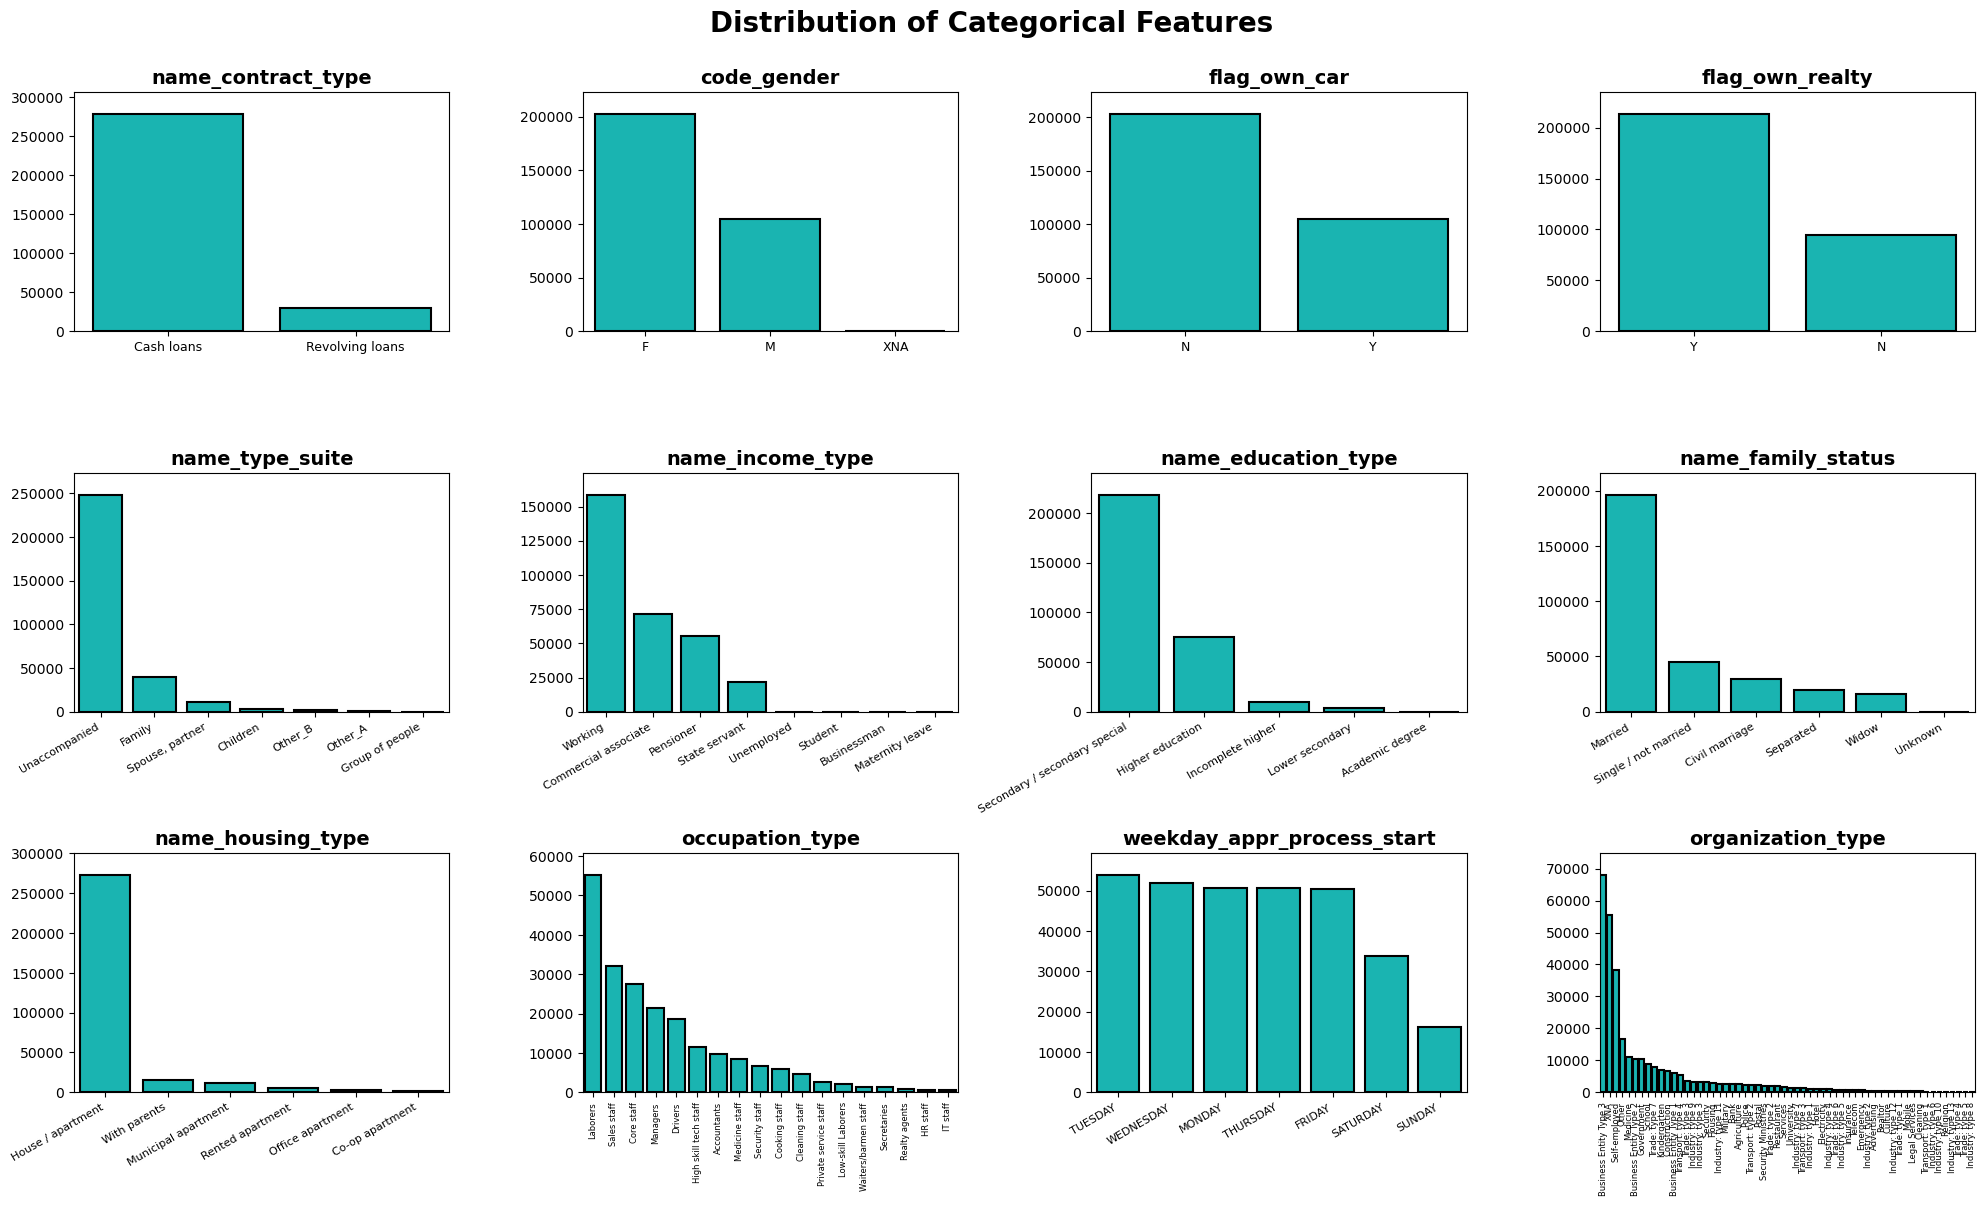

In [24]:
# Distribution of Categorical Features
# Distribution plot confirms earlier merge decisions for rare categories.
fig, axes=plt.subplots(3, 4, figsize=(20, 12))
axes=axes.flatten()

for ax, col in zip(axes, cat_cols):
    bars=df[col].value_counts()
    sns.barplot(x=bars.index, y=bars.values, ax=ax, errorbar=None, color='#00CEC9', edgecolor='k', linewidth=1.5)
    ax.set_title(col, fontweight='bold', fontsize=14)
    ax.set_ylabel('')
    ax.set_xlabel('')
    if df[col].nunique() > 10:
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=90)
    elif df[col].nunique() > 4:
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=8, rotation=30, ha='right')
    else:
        ax.set_xticklabels(ax.get_xticklabels(), fontsize=9, rotation=0)
    ax.set_ylim(0, max(bars.values)*1.1)

for ax in axes[len(cat_cols):]:
    ax.set_visible(False)

plt.suptitle('Distribution of Categorical Features', fontweight='bold', fontsize=20, y=1.001)
plt.tight_layout()
plt.show()

In [25]:
# Filter only columns with NaN
nans=df.isnull().sum()
nan_=nans[nans>0].sort_values(ascending=False)
nan_

ext_source_1                173378
occupation_type              96391
ext_source_3                 60965
name_type_suite               1292
obs_30_cnt_social_circle      1021
def_30_cnt_social_circle      1021
obs_60_cnt_social_circle      1021
def_60_cnt_social_circle      1021
ext_source_2                   660
amt_goods_price                278
amt_annuity                     12
cnt_fam_members                  2
days_last_phone_change           1
dtype: int64

In [26]:
# Create a DataFrame showing missing value count and percentage for columns with NaN
missing=pd.DataFrame({'missing_cnt':df[nan_.index].isnull().sum(),
                      'missing_pct':(df[nan_.index].isnull().sum()/df.shape[0]*100).round(2)})
missing

,missing_cnt,missing_pct
ext_source_1,173378,56.38
occupation_type,96391,31.35
ext_source_3,60965,19.83
name_type_suite,1292,0.42
obs_30_cnt_social_circle,1021,0.33
def_30_cnt_social_circle,1021,0.33
obs_60_cnt_social_circle,1021,0.33
def_60_cnt_social_circle,1021,0.33
ext_source_2,660,0.21
amt_goods_price,278,0.09


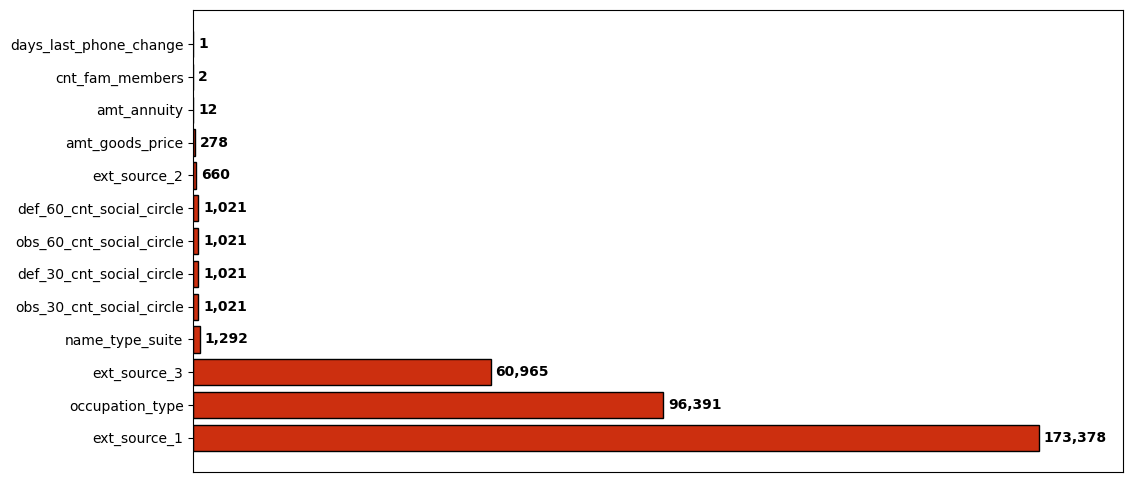

In [27]:
# Plot number of missing values per feature
plt.figure(figsize=(12,6))
bars=plt.barh(width=nan_.values, y=nan_.index, edgecolor='k', color='#CC2F0F')
for bar in bars:
    width=bar.get_width()
    plt.text(width+1000, bar.get_y()+bar.get_height()/2,
             f'{int(width):,}', va='center', fontweight='bold')
plt.xticks([])
plt.xlim(0, nan_.max()*1.1);

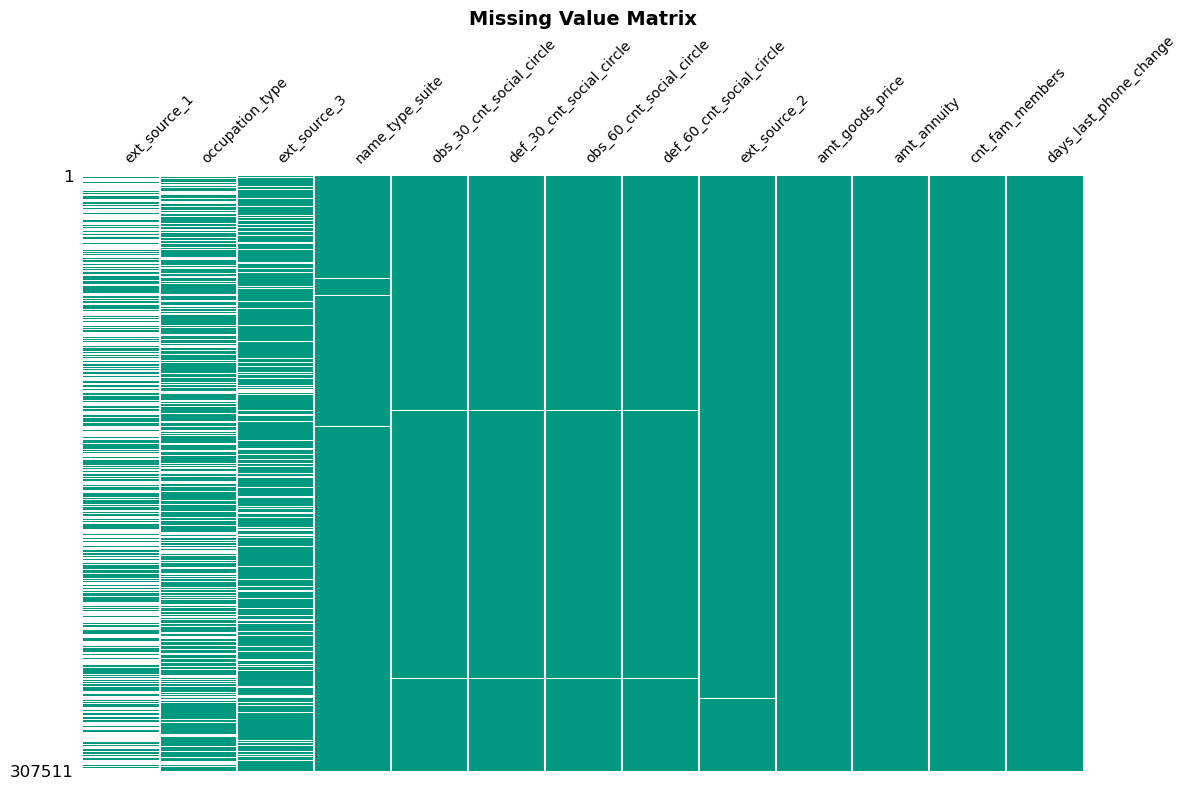

In [28]:
# Visual map of missing values — easier to spot patterns than reading numbers
fig, ax = plt.subplots(figsize=(12, 8))
msno.matrix(df[nan_.index], ax=ax, fontsize=10, color=(0.0, 0.6, 0.5))
plt.title('Missing Value Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
'''A threshold of 0.05 is commonly used for statistical significance 
based on the classical hypothesis testing framework 
introduced by Fisher and later formalized by Neyman and Pearson.'''

results=[]
for col in nan_.index:
    missing_indicator=df[col].isnull().astype(int)
    contingency_table=pd.crosstab(missing_indicator, df['target'])
    chi2, p_value, dof, expected=chi2_contingency(contingency_table)
    results.append([f'{col}_missing', chi2, p_value])
results_df=pd.DataFrame(results, columns=['feature', 'chi2', 'p_value'])
results_df=results_df.sort_values('chi2', ascending=False).reset_index(drop=True)
results_df[results_df['p_value']<0.05] #['feature'].to_list()


,feature,chi2,p_value
0,occupation_type_missing,460.001015,4.804746e-102
1,ext_source_3_missing,157.091017,4.889468e-36
2,ext_source_1_missing,106.715391,5.139197e-25
3,obs_30_cnt_social_circle_missing,27.927247,1.259634e-07
4,def_30_cnt_social_circle_missing,27.927247,1.259634e-07
5,obs_60_cnt_social_circle_missing,27.927247,1.259634e-07
6,def_60_cnt_social_circle_missing,27.927247,1.259634e-07
7,name_type_suite_missing,11.966556,5.416397e-04


In [30]:
# Show summary statistics for numerical columns
with pd.option_context('display.max_columns', None):
    print(df[num_cols].describe())

              target   cnt_children  amt_income_total    amt_credit  \
count  307511.000000  307511.000000      3.075110e+05  3.075110e+05   
mean        0.080729       0.417052      1.687979e+05  5.990260e+05   
std         0.272419       0.722121      2.371231e+05  4.024908e+05   
min         0.000000       0.000000      2.565000e+04  4.500000e+04   
25%         0.000000       0.000000      1.125000e+05  2.700000e+05   
50%         0.000000       0.000000      1.471500e+05  5.135310e+05   
75%         0.000000       1.000000      2.025000e+05  8.086500e+05   
max         1.000000      19.000000      1.170000e+08  4.050000e+06   

         amt_annuity  amt_goods_price  region_population_relative  \
count  307499.000000     3.072330e+05               307511.000000   
mean    27108.573909     5.383962e+05                    0.020868   
std     14493.737315     3.694465e+05                    0.013831   
min      1615.500000     4.050000e+04                    0.000290   
25%     16524.0

In [31]:
# Identify binary numeric features (columns with exactly two unique values)
num_binary=df[num_cols].nunique()==2
binary_cols=num_binary[num_binary.values].index.to_list()
print(f'{len(binary_cols)} binary_cols: {binary_cols}')

7 binary_cols: ['target', 'flag_emp_phone', 'flag_work_phone', 'flag_phone', 'reg_city_not_live_city', 'reg_city_not_work_city', 'live_city_not_work_city']


In [32]:
# Select non-binary numeric features for further analysis
num_others=[col for col in num_cols if col not in binary_cols]
print(f'{len(num_others)} other_num_cols: {num_others}')

23 other_num_cols: ['cnt_children', 'amt_income_total', 'amt_credit', 'amt_annuity', 'amt_goods_price', 'region_population_relative', 'days_birth', 'days_employed', 'days_registration', 'days_id_publish', 'cnt_fam_members', 'region_rating_client', 'hour_appr_process_start', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'obs_30_cnt_social_circle', 'def_30_cnt_social_circle', 'obs_60_cnt_social_circle', 'def_60_cnt_social_circle', 'days_last_phone_change', 'total_documents', 'total_enquiries']


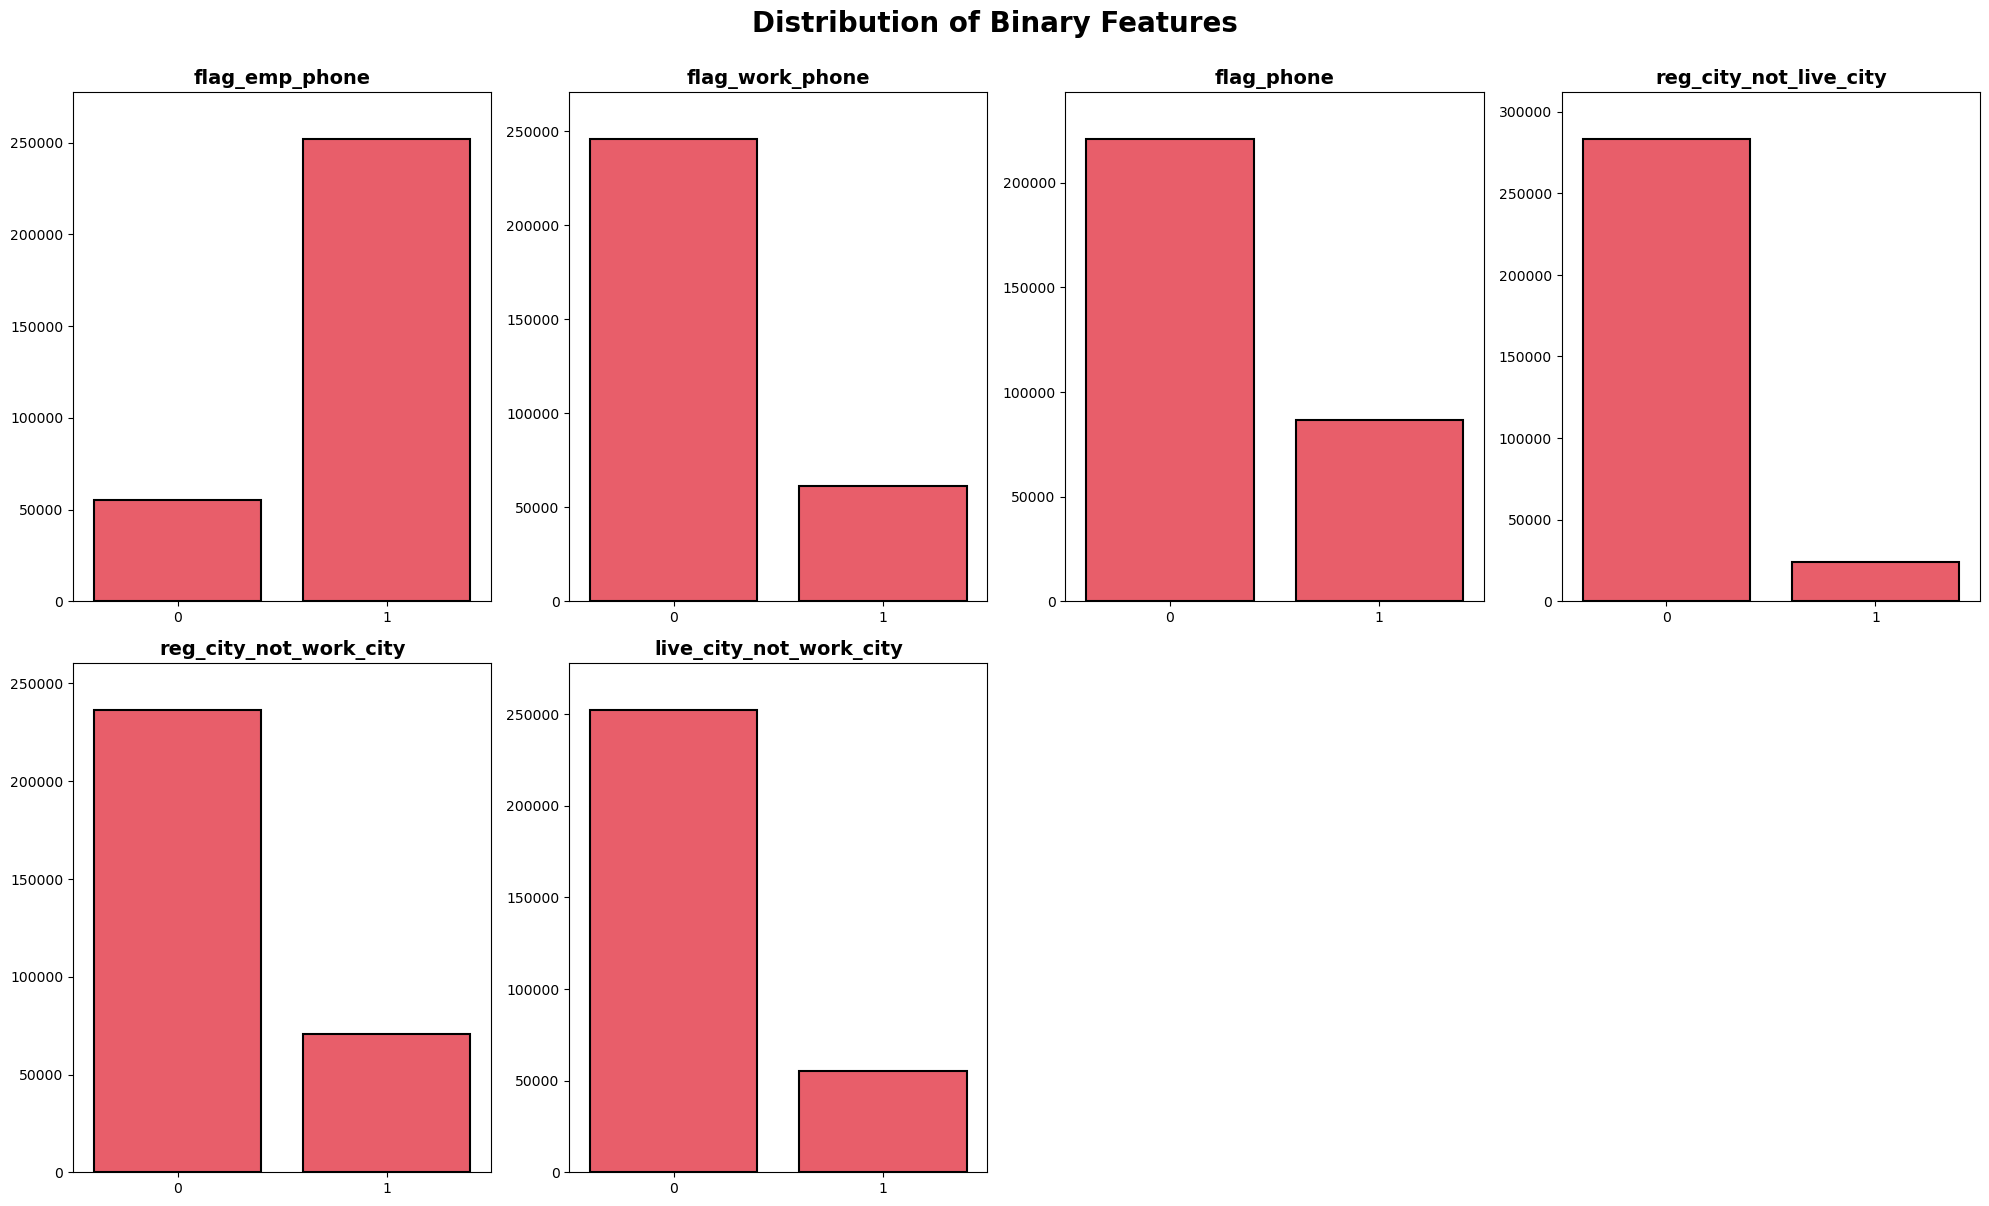

In [33]:
# Distribution of Binary Features
fig, axes=plt.subplots(2, 4, figsize=(20, 12))
axes=axes.flatten()
cols=[col for col in binary_cols if col!='target']

for ax, col in zip(axes, cols):
    bars=df[col].value_counts()
    sns.barplot(x=bars.index, y=bars.values, ax=ax, errorbar=None, color='#FF4757', edgecolor='k', linewidth=1.5)
    ax.set_title(col, fontweight='bold', fontsize=14)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_ylim(0, max(bars.values)*1.1)

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.suptitle('Distribution of Binary Features', fontweight='bold', fontsize=20, y=1.001)
plt.tight_layout()
plt.show()

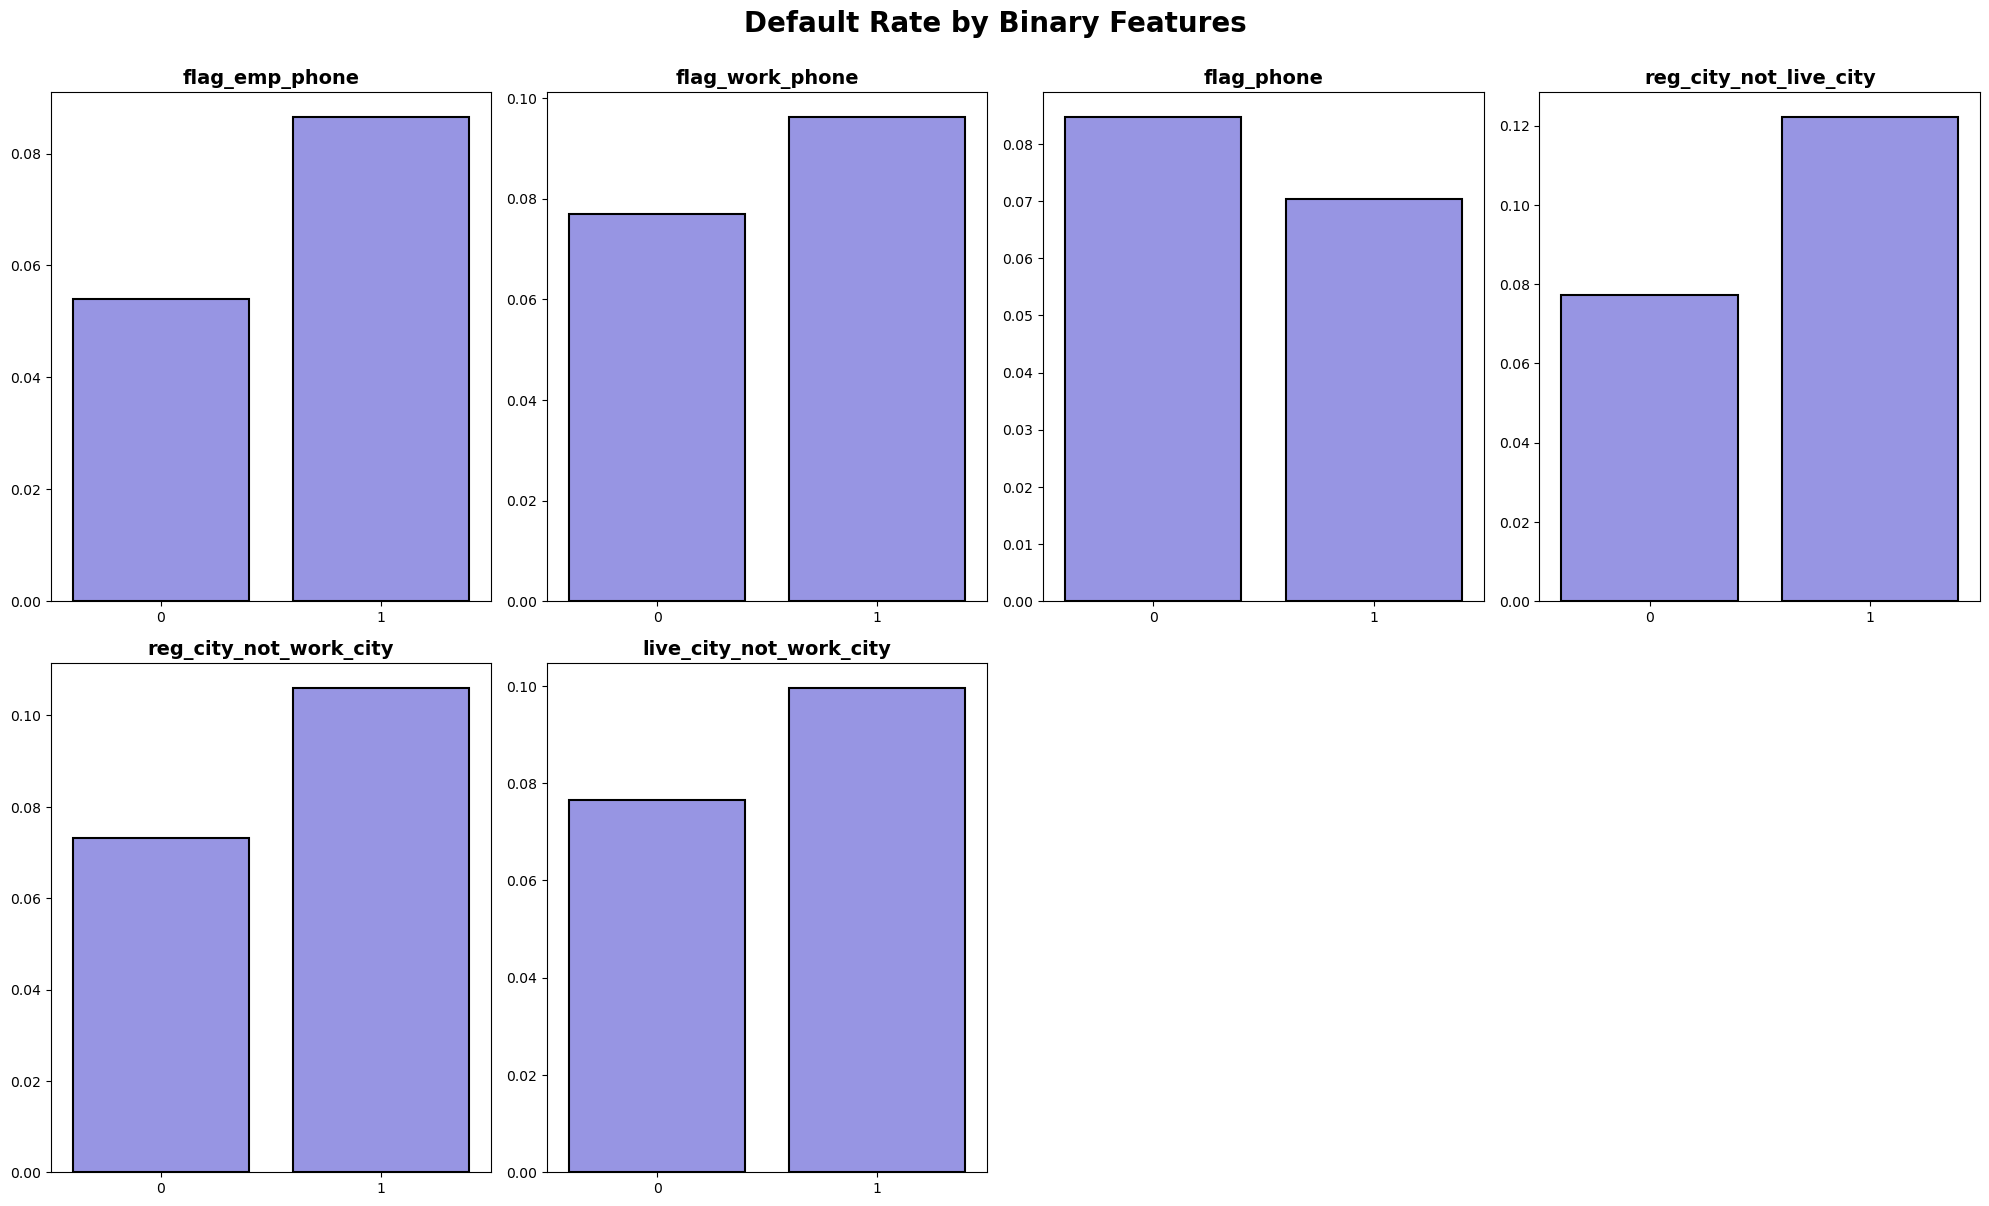

In [34]:
# Default Rate by Binary Features
fig, axes=plt.subplots(2, 4, figsize=(20, 12))
axes=axes.flatten()
cols=[col for col in binary_cols if col!='target']

for ax, col in zip(axes, cols):
    sns.barplot(x=df[col], y=df['target'], ax=ax, errorbar=None, color='#8B88F0', edgecolor='k', linewidth=1.5)
    ax.set_title(col, fontweight='bold', fontsize=14)
    ax.set_ylabel('')
    ax.set_xlabel('')

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.suptitle('Default Rate by Binary Features', fontweight='bold', fontsize=20, y=1.001)
plt.tight_layout()
plt.show()

In [35]:
# Skewness measures the asymmetry of the distribution.
results=[]
for col in num_others:
    skew=df[col].skew()
    mark='normal' if abs(skew)<1 else 'high'
    results.append({'col':col, 'skewness':skew, 'mark':mark})
skew_df=pd.DataFrame(results).sort_values('skewness', ascending=False).reset_index(drop=True)
display(skew_df)
high_skew_cols=skew_df[skew_df['mark']=='high']['col'].to_list()
print(f'high_skew_cols ({len(high_skew_cols)}): {high_skew_cols}')
normal_skew_cols=[col for col in num_others if col not in high_skew_cols]
print(f'normal_skew_cols ({len(normal_skew_cols)}): {normal_skew_cols}')

,col,skewness,mark
0,amt_income_total,391.559654,high
1,obs_30_cnt_social_circle,12.139598,high
2,obs_60_cnt_social_circle,12.070829,high
3,total_enquiries,6.119473,high
4,def_60_cnt_social_circle,5.277878,high
5,def_30_cnt_social_circle,5.183518,high
6,cnt_children,1.974604,high
7,days_employed,1.664346,high
8,amt_annuity,1.579777,high
9,region_population_relative,1.488009,high


high_skew_cols (13): ['amt_income_total', 'obs_30_cnt_social_circle', 'obs_60_cnt_social_circle', 'total_enquiries', 'def_60_cnt_social_circle', 'def_30_cnt_social_circle', 'cnt_children', 'days_employed', 'amt_annuity', 'region_population_relative', 'amt_goods_price', 'amt_credit', 'total_documents']
normal_skew_cols (10): ['days_birth', 'days_registration', 'days_id_publish', 'cnt_fam_members', 'region_rating_client', 'hour_appr_process_start', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'days_last_phone_change']


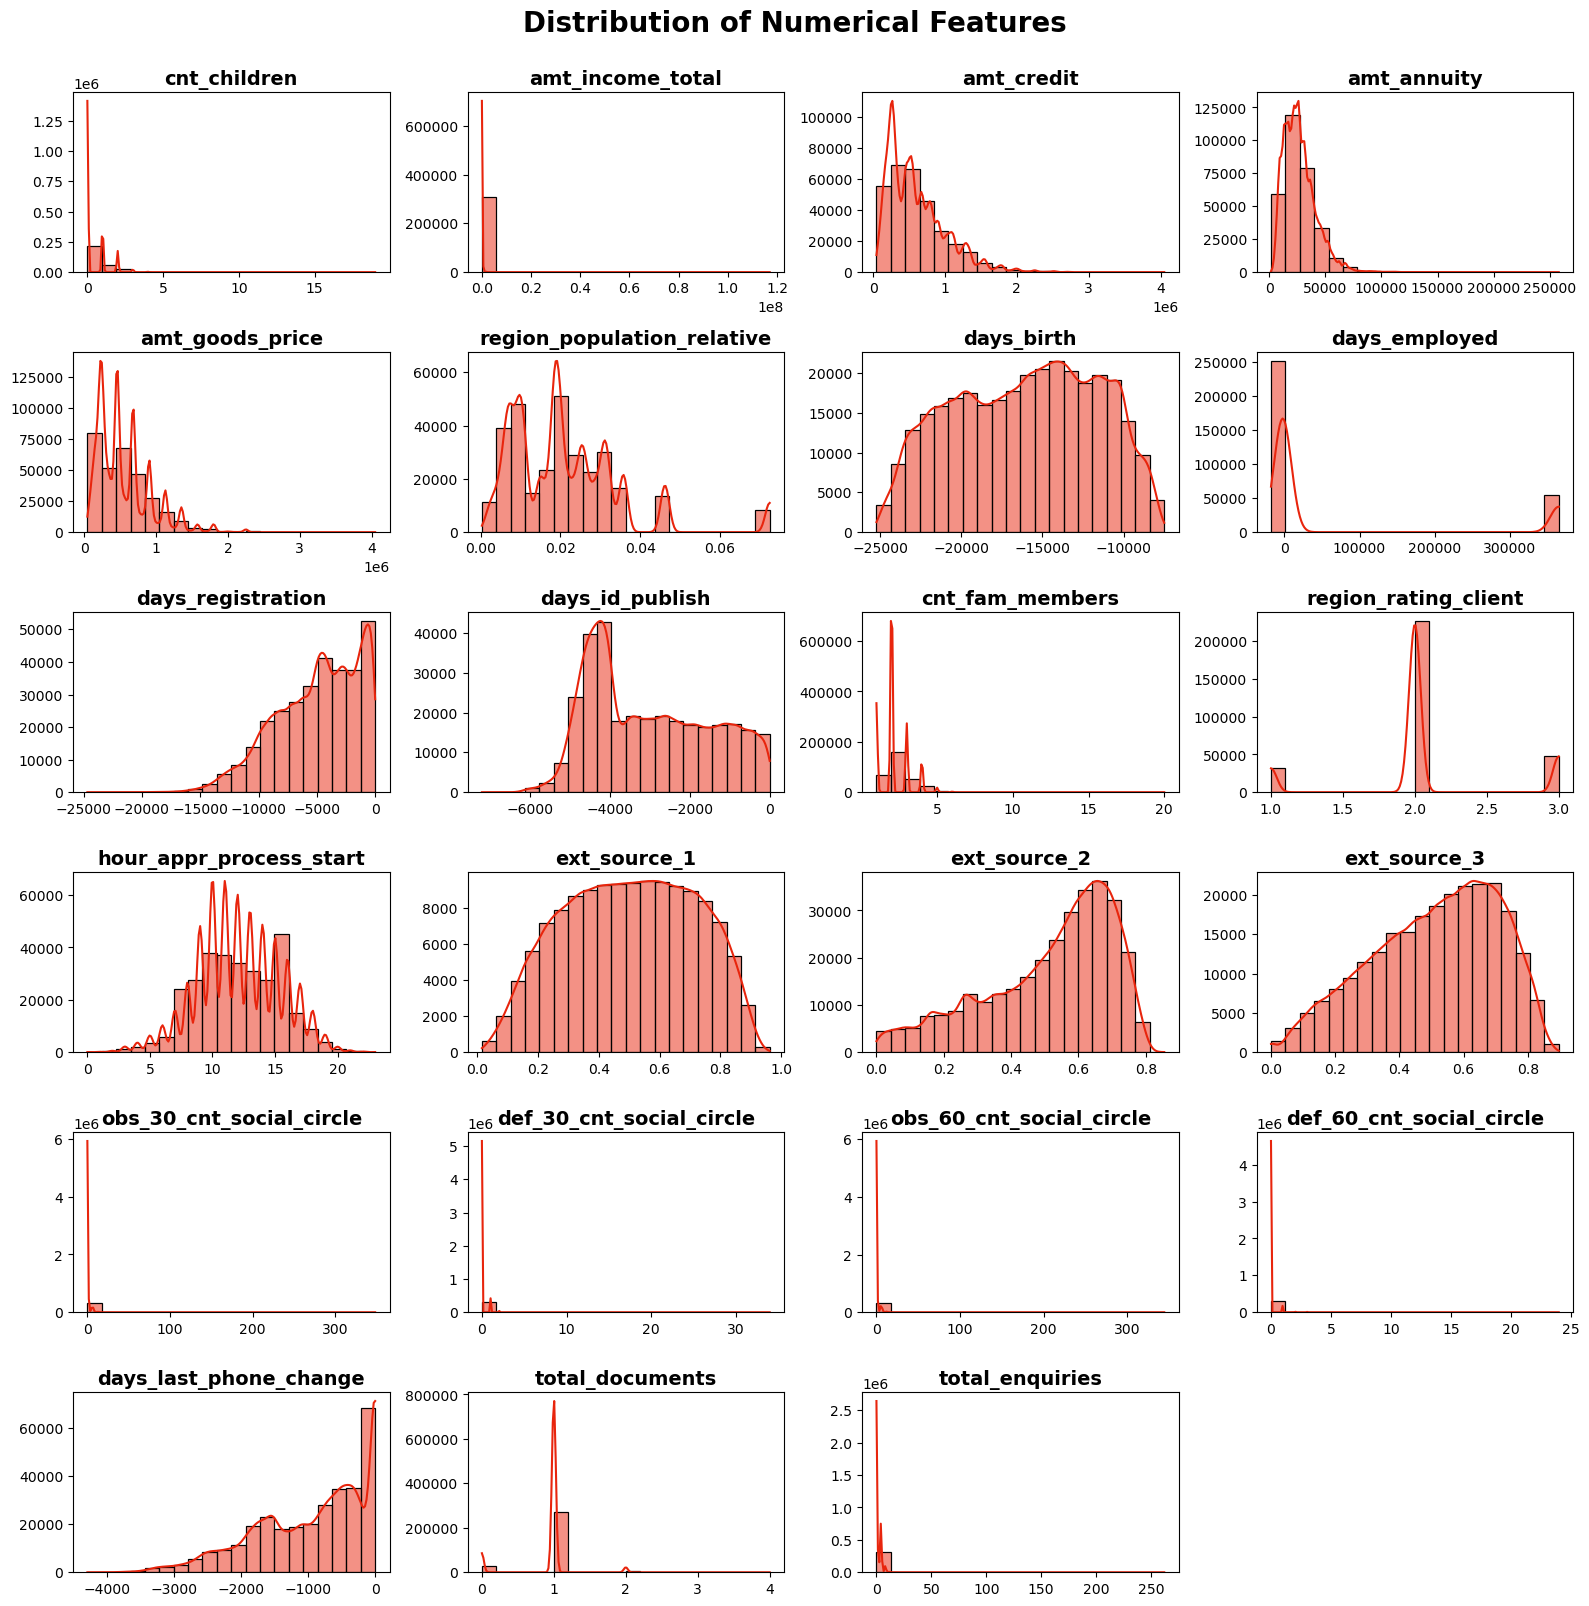

In [36]:
# Visualize numerical distributions to inspect skewness and detect outliers
fig, ax = plt.subplots(6, 4, figsize=(16, 16))
axes=ax.flatten()

for ax, col in enumerate(num_others):
    sns.histplot(df[col], ax=axes[ax], bins=20, kde=True, color='#E8250D')
    axes[ax].set_title(col, fontweight='bold', fontsize=14)
    axes[ax].set_ylabel('')
    axes[ax].set_xlabel('')

for ax in axes[len(num_others):]:
    ax.set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontweight='bold', fontsize=20, y=1.001)
plt.tight_layout()
plt.show()

In [37]:
# Kurtosis measures the heaviness of the tails (presence of outliers).
# High kurtosis (>1) confirms extreme values → consistent with boxplot analysis.
results=[]
for col in num_others:
    kurt=df[col].kurt()
    mark='normal' if abs(kurt)<1 else 'high'
    results.append({'col':col, 'kurtosis':kurt, 'mark':mark})
kurt_df=pd.DataFrame(results).sort_values('kurtosis', ascending=False).reset_index(drop=True)
display(kurt_df)
high_kurt_cols=kurt_df[kurt_df['mark']=='high']['col'].to_list()
print(f'high_kurt_cols ({len(high_kurt_cols)}): {high_kurt_cols}')
high_kurt_not_skew=[col for col in high_kurt_cols if col not in high_skew_cols]
print(f'high_kurt_not_skew ({len(high_kurt_not_skew)}): {high_kurt_not_skew}')

,col,kurtosis,mark
0,amt_income_total,191786.554381,high
1,obs_30_cnt_social_circle,1424.815552,high
2,obs_60_cnt_social_circle,1409.704557,high
3,total_enquiries,541.418916,high
4,def_30_cnt_social_circle,126.312445,high
5,def_60_cnt_social_circle,86.562856,high
6,cnt_children,7.904106,high
7,amt_annuity,7.707320,high
8,total_documents,5.180791,high
9,region_population_relative,3.260065,high


high_kurt_cols (15): ['amt_income_total', 'obs_30_cnt_social_circle', 'obs_60_cnt_social_circle', 'total_enquiries', 'def_30_cnt_social_circle', 'def_60_cnt_social_circle', 'cnt_children', 'amt_annuity', 'total_documents', 'region_population_relative', 'cnt_fam_members', 'amt_goods_price', 'amt_credit', 'days_birth', 'days_id_publish']
high_kurt_not_skew (3): ['cnt_fam_members', 'days_birth', 'days_id_publish']


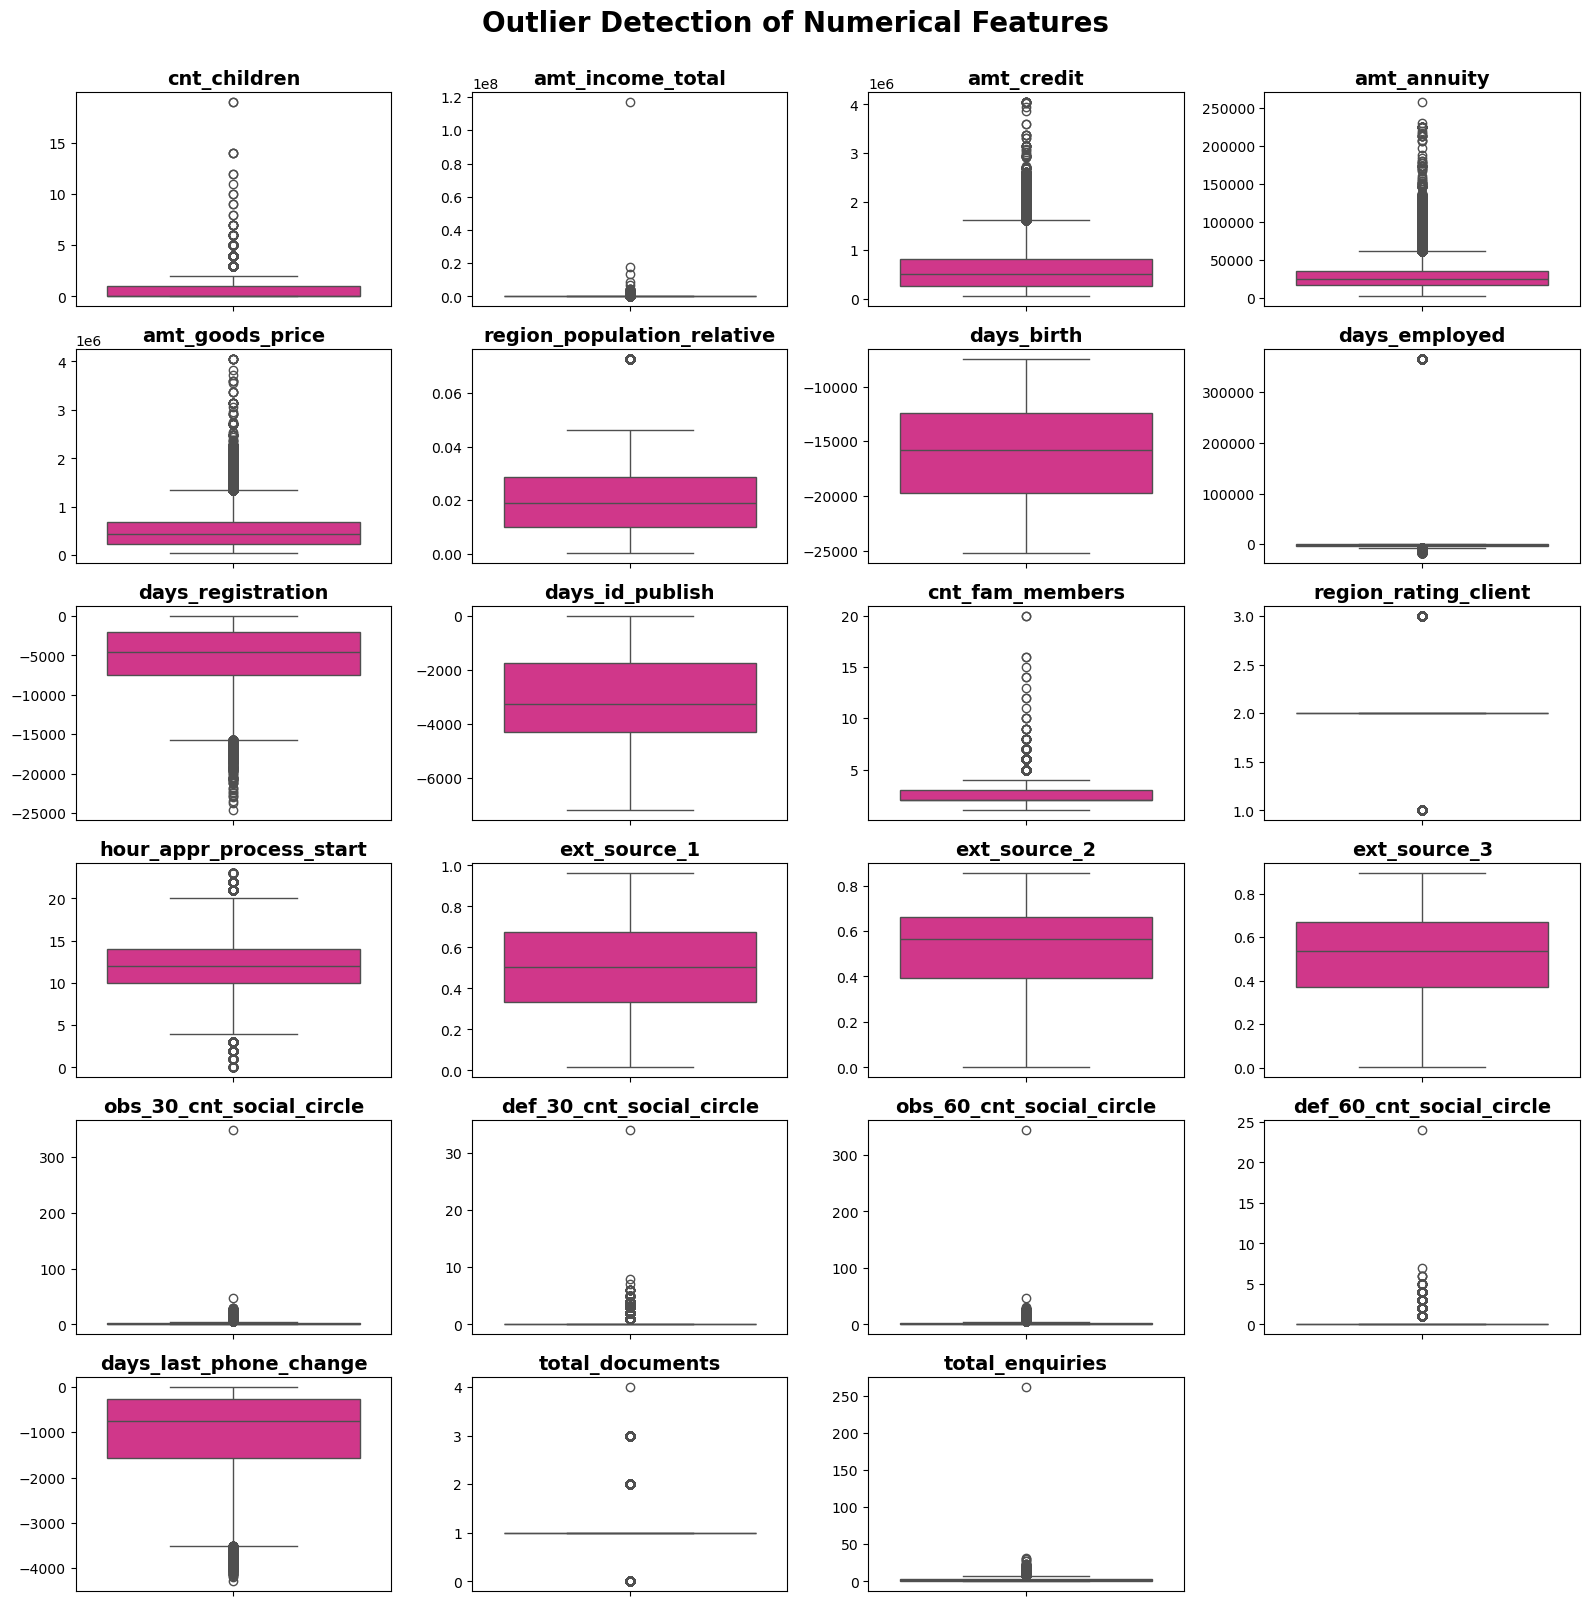

In [38]:
# Visualize numerical columns with boxplots to spot outliers
fig, ax = plt.subplots(6, 4, figsize=(16, 16))
axes=ax.flatten()

for ax, col in enumerate(num_others):
    sns.boxplot(df[col], ax=axes[ax], color="#E91E8C")
    axes[ax].set_title(col, fontweight='bold', fontsize=14)
    axes[ax].set_ylabel('')
    axes[ax].set_xlabel('')

for ax in axes[len(num_others):]:
    ax.set_visible(False)

plt.suptitle('Outlier Detection of Numerical Features', fontweight='bold', fontsize=20, y=1.001)
plt.tight_layout()
plt.show()

In [39]:
'''Detect outliers in continuous numeric features using the IQR method
outlier_default: mean target rate among outlier rows
normal_default: mean target rate among non-outlier rows
if diff is small -> outliers have no meaningful impact on target -> safe to transform
if diff is large -> outliers carry predictive signal -> keep as-is'''
'''diff = 0.04 represents a 50% change in default rate → outliers carry meaningful signal
However, these columns are already planned for log1p → transformation compresses 
extreme values but preserves the signal (does not remove outliers, just reduces their scale)'''
results=[]
for col in num_others:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    outliers=(df[col]<lower) | (df[col]>upper)
    outlier_cnt=len(df[outliers])
    outlier_pct=round(outlier_cnt/len(df)*100, 2)
    outlier_default=round(df[outliers]['target'].mean(), 2)
    normal_default=round(df[~outliers]['target'].mean(), 2)
    results.append({'column':col, 'outlier_cnt':outlier_cnt, 'outlier_pct':outlier_pct, 'outlier_default':outlier_default, 'diff':abs(normal_default-outlier_default)})

outlier_df=pd.DataFrame(results).sort_values('outlier_cnt', ascending=False).reset_index(drop=True)
display(outlier_df)
have_outlier=outlier_df[outlier_df['outlier_pct']>0]['column'].to_list()
print(f'Features with outliers ({len(have_outlier)}):{have_outlier}')
no_outlier=[col for col in num_others if col not in have_outlier]
print(f'Features with no outlier ({len(no_outlier)}):{no_outlier}')
not_in_log_cols=[col for col in have_outlier if col not in high_skew_cols]
print(f'Features not in high_skew_cols with outlier ({len(not_in_log_cols)}):{not_in_log_cols}')

,column,outlier_cnt,outlier_pct,outlier_default,diff
0,region_rating_client,80527,26.19,0.09,0.01
1,days_employed,72217,23.48,0.05,0.04
2,total_documents,37455,12.18,0.05,0.03
3,def_30_cnt_social_circle,35166,11.44,0.10,0.02
4,def_60_cnt_social_circle,25769,8.38,0.11,0.03
5,obs_30_cnt_social_circle,19971,6.49,0.09,0.01
6,obs_60_cnt_social_circle,19564,6.36,0.09,0.01
7,amt_goods_price,14728,4.79,0.04,0.04
8,amt_income_total,14035,4.56,0.06,0.02
9,total_enquiries,8536,2.78,0.08,0.00


Features with outliers (18):['region_rating_client', 'days_employed', 'total_documents', 'def_30_cnt_social_circle', 'def_60_cnt_social_circle', 'obs_30_cnt_social_circle', 'obs_60_cnt_social_circle', 'amt_goods_price', 'amt_income_total', 'total_enquiries', 'region_population_relative', 'amt_annuity', 'amt_credit', 'cnt_children', 'cnt_fam_members', 'hour_appr_process_start', 'days_registration', 'days_last_phone_change']
Features with no outlier (5):['days_birth', 'days_id_publish', 'ext_source_1', 'ext_source_2', 'ext_source_3']
Features not in high_skew_cols with outlier (5):['region_rating_client', 'cnt_fam_members', 'hour_appr_process_start', 'days_registration', 'days_last_phone_change']


In [40]:
# Zero values are valid in all columns and represent real-world scenarios.
# If zeros were invalid, they would be replaced with NaN and imputed
results=[]
for col in num_others:
    zero_check=df[col].value_counts().get(0, 0)
    results.append({'column':col, 'zero_count':zero_check})
zero_df=pd.DataFrame(results).sort_values('zero_count', ascending=False).reset_index(drop=True)
zero_df

,column,zero_count
0,def_60_cnt_social_circle,280721
1,def_30_cnt_social_circle,271324
2,cnt_children,215371
3,obs_60_cnt_social_circle,164666
4,obs_30_cnt_social_circle,163910
5,total_enquiries,92430
6,days_last_phone_change,37672
7,total_documents,29549
8,days_registration,80
9,hour_appr_process_start,40


In [41]:
corr=df.corr(numeric_only=True)

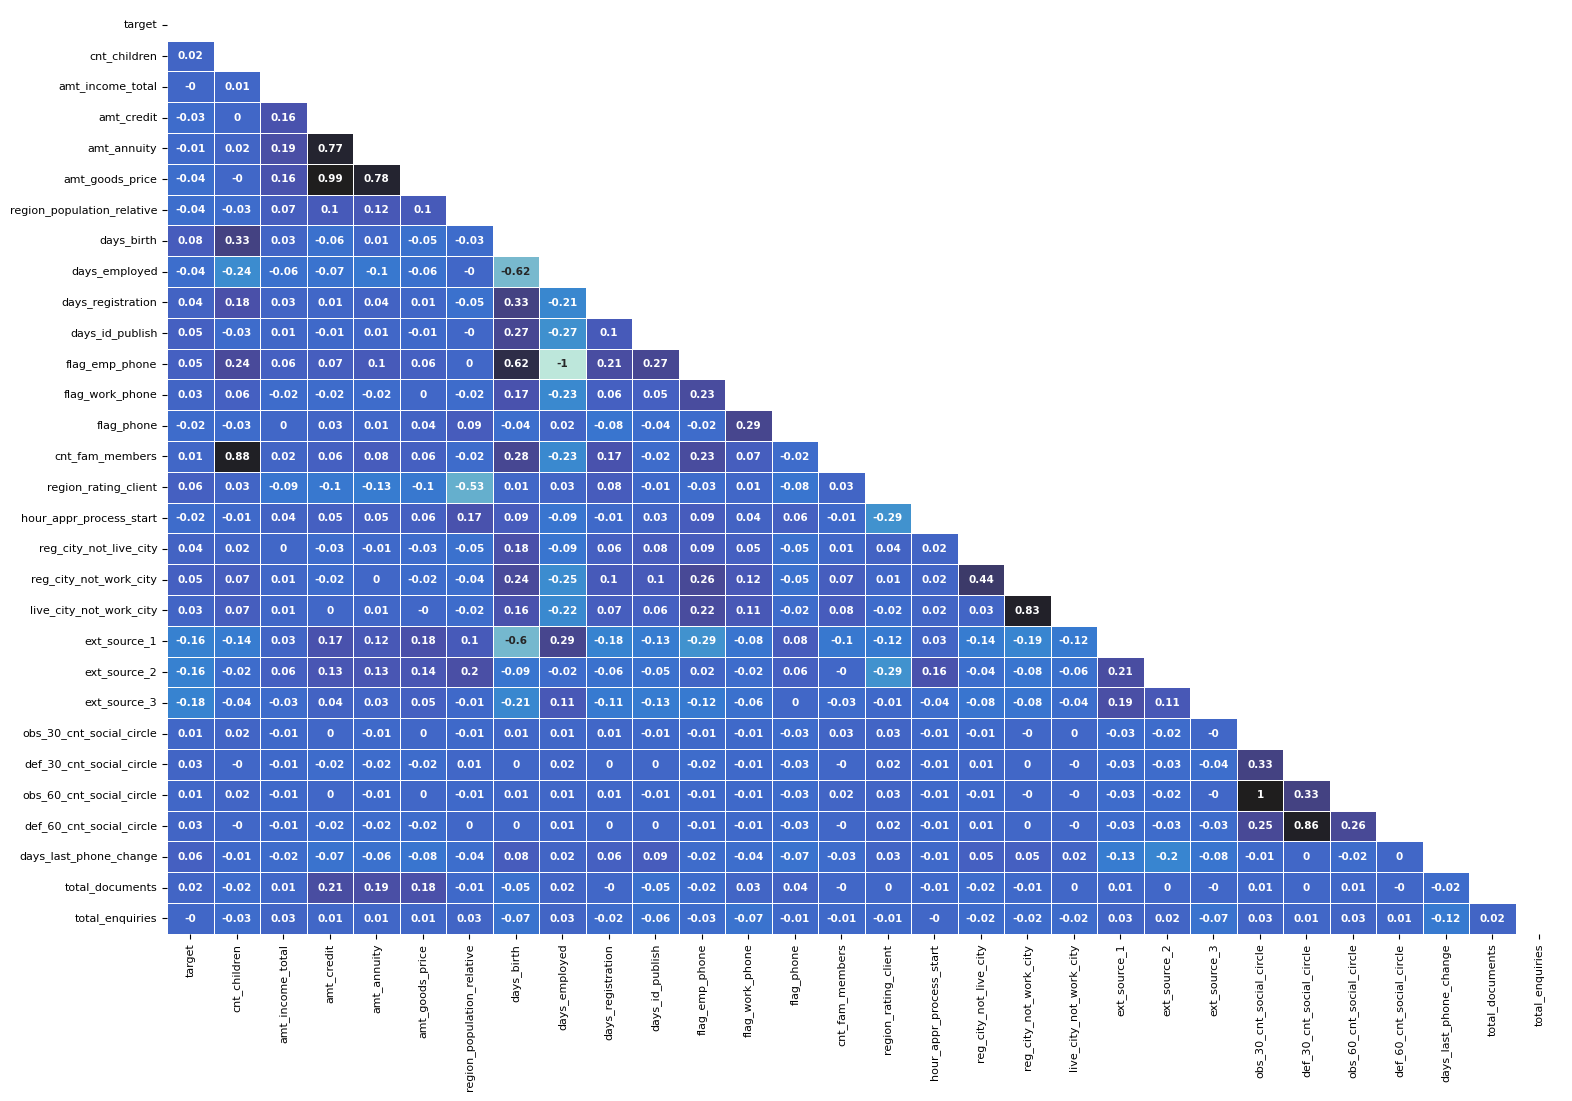

In [42]:
# Correlation heatmap to detect multicollinearity between numeric features
mask=np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(18,12))
sns.heatmap(round(corr, 2), cbar=False, center=True, annot=True, mask=mask, linewidths=0.5,
             linecolor='white', annot_kws={'fontsize':7.5, 'fontweight':'bold'})
plt.xticks(fontsize=8)
plt.yticks(fontsize=8);

In [43]:
'''Correlation threshold of 0.8 is used to detect multicollinearity —
two features sharing the same information → one can be dropped.
Threshold based on Hair et al. — Multivariate Data Analysis.'''
'''I used 0.75 instead of 0.8 as a more conservative threshold
to detect multicollinearity earlier and reduce feature redundancy,
since correlation thresholds are not strictly fixed and
can vary depending on the dataset and modeling goals.'''
high_corr=[]
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        if abs(corr.iloc[i, j])>=0.75:
            high_corr.append({
                'feature_1': corr.columns[i],
                'feature_2': corr.columns[j],
                'correlation': round(corr.iloc[i, j], 3)
            })
corr_df=pd.DataFrame(high_corr).sort_values('correlation', ascending=False).reset_index(drop=True)
corr_df

,feature_1,feature_2,correlation
0,obs_30_cnt_social_circle,obs_60_cnt_social_circle,0.998
1,amt_credit,amt_goods_price,0.987
2,cnt_children,cnt_fam_members,0.879
3,def_30_cnt_social_circle,def_60_cnt_social_circle,0.861
4,reg_city_not_work_city,live_city_not_work_city,0.826
5,amt_annuity,amt_goods_price,0.775
6,amt_credit,amt_annuity,0.770
7,days_employed,flag_emp_phone,-1.000


In [44]:
# Correlation of each numeric feature with the target variable
print(f'Correlation with target:\n{corr['target'].drop('target').sort_values(key=abs, ascending=False).round(4)}')

Correlation with target:
ext_source_3                 -0.1789
ext_source_2                 -0.1605
ext_source_1                 -0.1553
days_birth                    0.0782
region_rating_client          0.0589
days_last_phone_change        0.0552
days_id_publish               0.0515
reg_city_not_work_city        0.0510
flag_emp_phone                0.0460
days_employed                -0.0449
reg_city_not_live_city        0.0444
days_registration             0.0420
amt_goods_price              -0.0396
region_population_relative   -0.0372
live_city_not_work_city       0.0325
def_30_cnt_social_circle      0.0322
def_60_cnt_social_circle      0.0313
amt_credit                   -0.0304
flag_work_phone               0.0285
hour_appr_process_start      -0.0242
flag_phone                   -0.0238
cnt_children                  0.0192
total_documents               0.0172
amt_annuity                  -0.0128
cnt_fam_members               0.0093
obs_30_cnt_social_circle      0.0091
obs_60_cnt_so

In [45]:
target_pct=df['target'].value_counts(normalize=True).round(2)
target_pct

target
0    0.92
1    0.08
Name: proportion, dtype: float64

In [46]:
target=df['target'].value_counts().round(2)
target

target
0    282686
1     24825
Name: count, dtype: int64

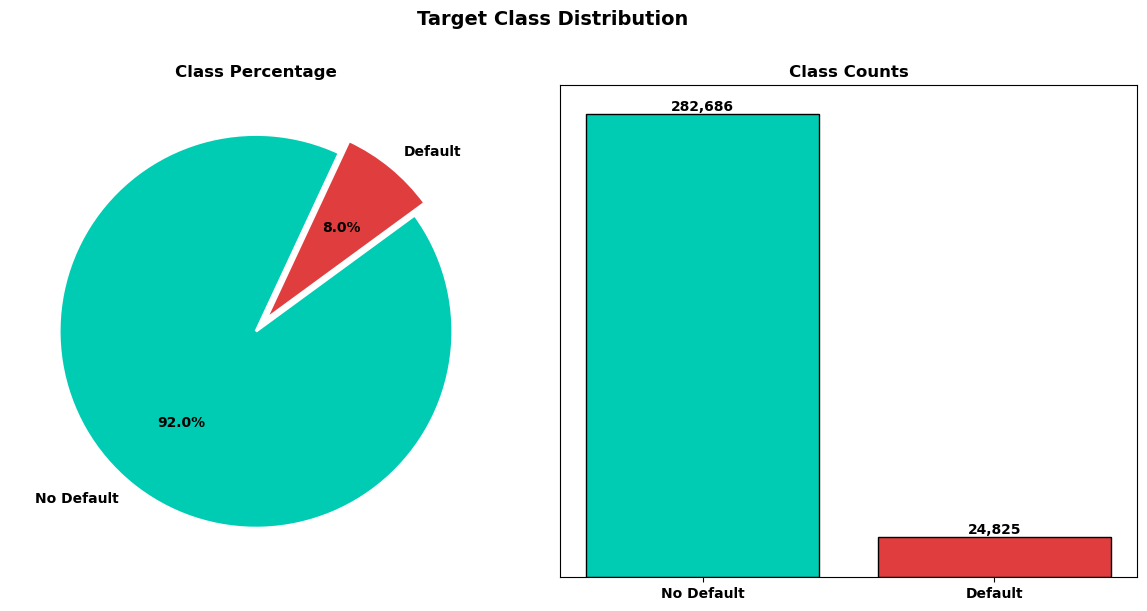

In [47]:
# Target class distribution

fig, ax = plt.subplots(1, 2, figsize=(12,6))

labels={0: 'No Default', 1: 'Default'}
colors=['#00CCB4', '#E03E3E']

# PIE CHART
ax[0].pie(target_pct, autopct='%1.1f%%', colors=colors, startangle=65, 
          wedgeprops={'edgecolor': 'white', 'linewidth': 2},
          textprops={'fontweight': 'bold', 'fontsize':10},  
          labels=target.index.map(labels),
          explode = [0, 0.08])

ax[0].set_title('Class Percentage', fontweight='bold')

# BAR CHART
bars=ax[1].bar(x=target.index, height=target.values, color=colors,
           edgecolor='k', linewidth=1)

for bar in bars:
    height=bar.get_height()
    ax[1].text(
        bar.get_x()+bar.get_width()/2, height, f'{int(height):,}',
        ha='center', va='bottom', fontweight='bold', 
    )

ax[1].set_title('Class Counts', fontweight='bold')
ax[1].set_xticks(target.index)
ax[1].set_xticklabels(target.index.map(labels), fontweight='bold')
ax[1].set_yticks([])
ax[1].set_ylim(0,300000)

plt.suptitle('Target Class Distribution', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---

## Findings

### Finding 1
Columns to convert to int64:<br>
['days_registration', 'obs_30_cnt_social_circle', 'obs_60_cnt_social_circle', 'cnt_fam_members',<br>
 'def_30_cnt_social_circle', 'def_60_cnt_social_circle', 'days_last_phone_change', 'years_employed', 'total_enquiries']

### Finding 2
`code_gender` column contains 4 rows with value `XNA` (represents unknown gender - `NaN`).<br>
`name_family_status` column contains `Unknown` values which represent missing data.<br>
`days_employed` contains a placeholder value (365243) that likely represents missing or anomalous data.<br>

Aurélien Géron — Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow<br>
If the missing values represent less than 1–5% of the dataset, dropping those rows is generally acceptable.

### Finding 3
Merging Rare Categories:<br>
According to the **Rare Label Encoding** technique (Galli, *Python Feature Engineering Cookbook*), <br>
categorical labels that appear in less than **1–5%** of observations <br>
should be grouped into a single `Other` / `Rare` category 
to reduce noise and avoid sparse representations after encoding.<br>
Rare categories (<5%) with similar default rates across groups → merging into 'Other'

**Affected columns:** <br>
merge_candidates = {<br>
    `name_type_suite`: ['Children', 'Group of people'],<br>
    `name_income_type`: ['Student', 'Businessman'],<br>
    `name_housing_type`: ['Co-op apartment', 'Office apartment'],<br>
    `occupation_type`: ['HR staff', 'IT staff', 'Private service staff', 'Realty agents', 'Secretaries'],<br>
    `organization_type`: ['Advertising', 'Culture', 'Electricity', 'Emergency', 'Government', 'Hotel', 'Housing', 'Industry: type 2', 
                          'Industry: type 5', 'Industry: type 6', 'Industry: type 7', 'Industry: type 9', 'Insurance', 'Kindergarten', 
                          'Legal Services', 'Postal', 'Religion', 'School', 'Services', 'Telecom', 'Trade: type 2', 'Trade: type 6', 'Transport: type 2']}

### Finding 4
MCAR = Missing Completely At Random.<br>
Missing values in these columns show no predictive power (p-value > 0.05 in chi-square test).<br>
MCAR confirmed + negligible count (~0.3%) -> rows will be dropped.<br>
no_predictive_missing = [
    'ext_source_2',
    'amt_goods_price',
    'amt_annuity',
    'cnt_fam_members',
    'days_last_phone_change'
]

### Finding 5
Missing values in these columns are not random (p-value < 0.05 in chi-square test) -> missingness carries predictive signal -> missing indicator columns will be created.<br>
predictive_missing = [<br>
    'occupation_type',
    'ext_source_3',
    'ext_source_1',
    'def_30_cnt_social_circle',
    'obs_60_cnt_social_circle',
    'obs_30_cnt_social_circle',
    'def_60_cnt_social_circle',
    'name_type_suite'
]

### Finding 6
ext_source_1 and ext_source_3 are external credit scores (range 0-1).<br>
MCAR = Missing Completely At Random<br>
Since missingness is not random (MCAR rejected), missing values indicate the score was unavailable for that applicant, not missing by chance.<br>
Imputing with -1 signals absence of credit history to the model, as 0 is a valid score value and would introduce noise.<br>
ext_source_cols = ['ext_source_1', 'ext_source_3']<br>
Remaining columns imputed with median (numeric) or mode (categorical).
Median is preferred over mean as these features contain outliers.<br>
median_impute = ['def_30_cnt_social_circle', 'obs_30_cnt_social_circle', 'def_60_cnt_social_circle', 'obs_60_cnt_social_circle']<br>
mode_impute = ['occupation_type', 'name_type_suite']


### Finding 7
`flag_phone` and `reg_city_not_work_city` are the strongest binary predictors, showing the highest difference in default rates between 0 and 1 groups, <br>which is also confirmed by the `distribution of binary_cols` plot above.

### Finding 8
Strongest predictors: `flag_emp_phone`, `reg_city_not_live_city`, `reg_city_not_work_city` — <br>
meaningful difference in default rates across groups.<br>
Which is also confirmed by the `default rate of binary_cols` plot above.

### Finding 9
According to Hair et al. (*Multivariate Data Analysis*), skewness values greater than **1** <br>
indicate non-normal distributions that may affect model performance -> log1p transformation will be applied.<br>
Right-skewed distributions -> log1p transformation will be applied in preprocessing log1p is preferred over log to safely handle zero values (log(0) = -inf)<br>
Which is also confirmed by the `distribution of numeric features` plot above.<br>
log_cols = ['amt_income_total', 'obs_30_cnt_social_circle', 'obs_60_cnt_social_circle', 'total_enquiries', 'def_60_cnt_social_circle', 'def_30_cnt_social_circle', 'cnt_children', 'days_employed', 'amt_annuity', 'amt_goods_price', 'amt_credit', 'total_documents']<br>
Approximately normal or uniform -> no transformation needed<br>
no_transform_cols = [
    'cnt_fam_members', 'region_rating_client', 'hour_appr_process_start',
    'ext_source_1', 'ext_source_2', 'ext_source_3'
]<br>
Negative values -> log transformation not applicable, keep as-is<br>
negative_cols = [
    'days_birth', days_registration', 'days_id_publish', 'days_last_phone_change'
]<br>
Special cases:<br>
`region_rating_client` -> bimodal, ordinal values (1/2/3) -> treat as categorical (ordinal encoding)<br>
name_education_type is ordinal — there is a clear ranking from lowest to highest education level:<br>
Lower secondary < Secondary < Incomplete higher < Higher education < Academic degree<br>
OrdinalEncoder preserves this order, OneHotEncoder would lose it

### Finding 10
`cnt_fam_members` --> High kurtosis indicates extreme values (heavy tails). Outlier capping is recommended to limit their impact.

### Finding 11
Outliers detected in `log_cols` will be handled implicitly by log1p transformation — no additional treatment needed.<br>
`ext_source_1`, `ext_source_2`, `ext_source_3`, `days_birth` and `days_id_publish` contain no outliers -> stable, reliable features.<br>
No true outliers are present in `hour_appr_process_start`. Log transformation is not suitable as the feature is not skewed and represents cyclical time. <br>No removal is required; cyclical encoding (sin/cos) is recommended.

### Finding 12
obs_30 and obs_60 are perfectly correlated (1.0) -> drop one in preprocessing<br>
amt_goods_price and amt_credit (0.99) -> drop one in preprocessing<br>
cnt_children and cnt_fam_members (0.89) -> drop one in preprocessing<br>
def_30 and def_60 (0.86) -> drop one in preprocessing<br>
reg_city_not_work_city and live_city_not_work_city (0.83) -> drop one in preprocessing<br>
For correlated pairs (0.80> >0.75), keep both for now.<br>
Feature importance after model training will show which one to drop.<br>
Model itself will downweight redundant features.<br>
ext_source features are the strongest predictors -> must be kept despite high missing rate

---
# Feature Engineering

In [48]:
# Use a copy to avoid changing the original data by mistake
# DAYS_BIRTH is stored as negative days. Dividing by -365.25 converts it to positive years. 365.25 accounts for leap years.
# Encode the hour as cyclical features (sin, cos) to reflect its circular nature 
# and ensure that adjacent hours (example 23 and 0) are treated as close.
# Division by zero produces inf — replace with NaN to handle safely during imputation

class FeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        df=pd.DataFrame(X).copy()

        df['age_years'] = df['days_birth'] / -365.25
        df['employed_years'] = df['days_employed'].replace(365243, np.nan) / -365.25
        df['credit_income_ratio'] = df['amt_credit'] / df['amt_income_total']
        df['annuity_income_ratio'] = df['amt_annuity'] / df['amt_income_total']
        df['credit_duration'] = df['amt_credit'] / df['amt_annuity']
        df['employed_to_age_ratio'] = df['employed_years'] / df['age_years']

        df['sin_hour'] = np.sin(2 * np.pi * df['hour_appr_process_start'] / 24)
        df['cos_hour'] = np.cos(2 * np.pi * df['hour_appr_process_start'] / 24)

        df['ext_mean'] = df[['ext_source_1','ext_source_2','ext_source_3']].mean(axis=1)
        df['ext_std']  = df[['ext_source_1','ext_source_2','ext_source_3']].std(axis=1)
        df['ext_prod'] = df['ext_source_1'] * df['ext_source_2'] * df['ext_source_3']

        df.drop(columns=['days_birth', 'days_employed', 'hour_appr_process_start'], errors='ignore', inplace=True)

        df.replace([np.inf, -np.inf], np.nan, inplace=True)

        return df

## Correlated Feature Dropping

In [49]:
class CorrelatedFeatureDropper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8, random_state=42):
        self.threshold = threshold
        self.random_state = random_state

    def fit(self, X, y=None):
        self.high_corr = []
        df = pd.DataFrame(X)
        corr = df.corr(numeric_only=True)
        rng = np.random.default_rng(self.random_state)
        for i in range(len(corr.columns)):
            for j in range(i+1, len(corr.columns)):
                if abs(corr.iloc[i, j]) >= self.threshold:
                    feat_1 = corr.columns[i]
                    feat_2 = corr.columns[j]
                    group = [feat_1, feat_2]
                    keep = rng.choice(group)
                    for f in group:
                        if f != keep:
                            self.high_corr.append(f)
        self.high_corr = list(set(self.high_corr))
        return self
    
    def transform(self, X):
        df=pd.DataFrame(X).copy()
        df.drop(columns = self.high_corr, inplace=True, errors='ignore')
        return df

---
# Train-Test Split

In [50]:
X=df.drop(columns=['target'])
y=df['target']

X_train, X_test, y_train, y_test=train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f'Train_size: {X_train.shape}')
print(f'Test_size: {X_test.shape}')
print(f'\nTarget distribution in train:\n{y_train.value_counts(normalize=True).round(2)}')

Train_size: (246008, 41)
Test_size: (61503, 41)

Target distribution in train:
target
0    0.92
1    0.08
Name: proportion, dtype: float64


---
# Preprocessing / Custom Transformers

### InvalidValueCleaner
Some values like 'XNA' or 'Unknown' are essentially disguised nulls — they represent missing information but aren't recognized as NaN by pandas.<br>So they get replaced with proper np.nan to be handled later.

In [51]:
class InvalidValueCleaner(BaseEstimator, TransformerMixin):
    def __init__(self, placeholders = None):
        self.placeholders = placeholders or ['XNA', 'Unknown', 'unknown', '', ' ', 'nan', 'none', 'None', 'N/A']
    
    def fit(self, X, y=None):
        self.invalid_map={}
        X = pd.DataFrame(X)
        cat_cols = X.select_dtypes(include='object').columns.to_list()
        for col in cat_cols:
            uniques=X[col].unique()
            for unique in uniques:
                if unique in self.placeholders:
                    if col not in self.invalid_map:
                        self.invalid_map[col] = []
                    self.invalid_map[col].append(unique)
        return self
    
    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in self.invalid_map.keys():
            X[col] = X[col].replace(self.invalid_map[col], np.nan)
        return X

### DtypeFixer
Some columns are actually integers but stored as floats (e.g. 1.0, 2.0), which wastes memory and can cause type-related issues downstream.<br>These get converted to proper Int64.

In [52]:
class DtypeFixer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.convert_int = []
        X = pd.DataFrame(X)
        float_cols = X.select_dtypes(include='float').columns
        for col in float_cols:
            if X[col].min() >= 0:
                if X[col].dropna().apply(lambda x: x==int(x)).all():
                    self.convert_int.append(col)
        return self
    
    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in self.convert_int:
            X[col]=X[col].astype('Int64')
        return X

### MissingIndicator
Flags columns where missingness is correlated with the target — low p-value means the pattern of missing values carries predictive signal,<br>so instead of just dropping or imputing, a new binary column _missing is added to preserve that signal for the model.

In [53]:
class MissingIndicator(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.indicator_cols = []
        X = pd.DataFrame(X)
        cols = X.columns
        for col in cols:
            nans = X[col].isnull().sum()
            if nans > 0:
                missing_indicator = X[col].isnull().astype(int)
                contingency_table = pd.crosstab(missing_indicator, y)
                chi2, p_value, dof, expected = chi2_contingency(contingency_table)
                if p_value < self.threshold:
                    self.indicator_cols.append(col)
        return self
    
    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in self.indicator_cols:
            X[str(col)+'_missing'] = X[col].isnull().astype(int)
        return X

### RareCategoryMerger
Merges rare categories into 'other' — but only if the category is both infrequent (≤4%) and not meaningfully different from the rest in terms of target rate.<br>This way, truly predictive rare categories are preserved and only the noisy, insignificant ones get collapsed.

In [54]:
class RareCategoryMerger(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.04):
        self.threshold = threshold

    def fit(self, X, y):
        self.merge_map = {}
        X = pd.DataFrame(X)
        cat_cols = X.select_dtypes(include='object').columns.to_list()
        for col in cat_cols:
            proportions = X[col].value_counts(normalize=True)
            default_rates = y.groupby(X[col]).mean()
            for value in proportions.index:
                if proportions[value] <= self.threshold and default_rates[value] < y.mean() and default_rates.max() - default_rates.min() < 0.05:
                    if col not in self.merge_map:
                        self.merge_map[col] = []
                    self.merge_map[col].append(value)
        return self
    
    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in self.merge_map.keys():
            X[col] = X[col].replace(self.merge_map[col], 'other')
        return X

### OutlierCapper
OutlierCapper clips numeric columns to the 1st–99th percentile range, capping extreme values without removing rows.<br>Conservative bounds are used since a subsequent log1p transformation will compress the remaining skew further.

In [105]:
# log1p transformation will further compress extreme values,
# so conservative 1%-99% capping is sufficient

class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, lower_pct=0.01, upper_pct=0.99):
        self.lower_pct = lower_pct
        self.upper_pct = upper_pct

    def fit(self, X, y=None):
        self.boundaries = {}
        X = pd.DataFrame(X)
        for col in X.select_dtypes(exclude='object'):
            self.boundaries[col] = {
            'lower_boundary' : X[col].quantile(self.lower_pct),
            'upper_boundary' : X[col].quantile(self.upper_pct)}
        return self
    
    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in X.select_dtypes(exclude='object'):
            X[col] = X[col].clip(
                lower = self.boundaries[col]['lower_boundary'],
                upper = self.boundaries[col]['upper_boundary']
            )
        return X

### Log1pTransformer
Log1pTransformer applies log1p to numeric columns that are right-skewed (skewness ≥ 1) and non-negative,<br> while skipping low-cardinality columns that are likely binary or ordinal flags rather than continuous features.

In [56]:
class Log1pTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3):
        self.threshold=threshold

    def fit(self, X, y=None):
        self.log_cols = []
        X = pd.DataFrame(X)
        num_cols = X.select_dtypes(exclude = 'object').columns
        num_others = [col for col in num_cols if X[col].nunique() > self.threshold]
        for col in num_others:
            skewness = abs(X[col].skew())
            if X[col].min() >= 0 and skewness >= 1:
                self.log_cols.append(col)
        return self
    
    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy()
        for col in self.log_cols:
            X[col] = np.log1p(X[col])
        return X

---
# Pipeline

In [57]:
# Temporarily apply transformers to inspect column names and types
# before defining ColumnTransformer groups

temp = X_train.copy()

fe = FeatureEngineer()
temp = fe.fit_transform(temp, y_train)

cfd = CorrelatedFeatureDropper()
temp = cfd.fit_transform(temp, y_train)

ivc = InvalidValueCleaner()
temp = ivc.fit_transform(temp, y_train)

mi = MissingIndicator()
temp = mi.fit_transform(temp, y_train)

print('Categorical:', temp.select_dtypes(include='object').columns.to_list())
print('Numeric:', temp.select_dtypes(exclude='object').columns.to_list())

Categorical: ['name_contract_type', 'code_gender', 'flag_own_car', 'flag_own_realty', 'name_type_suite', 'name_income_type', 'name_education_type', 'name_family_status', 'name_housing_type', 'occupation_type', 'weekday_appr_process_start', 'organization_type']
Numeric: ['cnt_children', 'amt_income_total', 'amt_annuity', 'amt_goods_price', 'region_population_relative', 'days_registration', 'days_id_publish', 'flag_emp_phone', 'flag_work_phone', 'flag_phone', 'region_rating_client', 'reg_city_not_live_city', 'live_city_not_work_city', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'obs_30_cnt_social_circle', 'def_30_cnt_social_circle', 'days_last_phone_change', 'total_documents', 'total_enquiries', 'age_years', 'credit_income_ratio', 'annuity_income_ratio', 'credit_duration', 'employed_to_age_ratio', 'sin_hour', 'cos_hour', 'ext_mean', 'ext_std', 'name_type_suite_missing', 'occupation_type_missing', 'organization_type_missing', 'ext_source_1_missing', 'ext_source_3_missing', 'obs_30_cnt

In [58]:
def split_columns(df):

    categorical_cols = df.select_dtypes(include='object').columns.tolist()
    numeric_cols = df.select_dtypes(exclude='object').columns.tolist()

    return categorical_cols, numeric_cols

cat_cols, num_cols = split_columns(temp)

ext_cols = ['ext_source_1', 'ext_source_3']

ordinal_edu = [col for col in cat_cols if 'education' in col]
edu_order = [['Lower secondary', 'Secondary / secondary special',
               'Incomplete higher', 'Higher education', 'Academic degree']]

ordinal_rating = [col for col in num_cols if 'region_rating' in col]
rating_order = [[1, 2, 3]]

ohe_cols = [c for c in cat_cols if c not in ordinal_edu]

binary_cols = [c for c in num_cols if set(temp[c].dropna().unique()).issubset({0,1})]

negative_cols = [c for c in num_cols if 'days' in c]

passthrough_cols = [c for c in num_cols if 'missing' in c]

used_cols = set(ext_cols) | set(ordinal_rating) | set(binary_cols) | set(negative_cols) | set(passthrough_cols)

median_std_cols = [c for c in num_cols if c not in used_cols]

In [59]:
def build_pipeline(model):
    
    # Pipelines

    ext_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
        ('scaler', StandardScaler())
    ])

    med_std_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    mod_ord_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=edu_order))
    ])

    med_ord_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('encoder', OrdinalEncoder(categories=rating_order))
    ])

    # sparse_output=False --> Return dense array instead of sparse matrix for compatibility with pandas and numpy.
    # handle_unknown='ignore' --> Silently ignore unseen categories during transform — encodes them as all zeros instead of raising an error.
    mod_ohe_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])

    # Uses median and IQR instead of mean and std — robust to outliers since extreme values do not affect the median
    med_rob_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ])

    binary_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    preprocessor = ColumnTransformer(transformers=[
    ('ext',     ext_pipe,     ext_cols),
    ('median',  med_std_pipe, median_std_cols),
    ('ord_edu', mod_ord_pipe, ordinal_edu),
    ('ord_rat', med_ord_pipe, ordinal_rating),
    ('ohe',     mod_ohe_pipe, ohe_cols),
    ('robust',  med_rob_pipe, negative_cols),
    ('binary',  binary_pipe,  binary_cols),
    ('pass',    'passthrough', passthrough_cols)
])
    
    return Pipeline([
    ('feature_engineer',  FeatureEngineer()),
    ('corr_dropper',      CorrelatedFeatureDropper()),
    ('invalid_cleaner',   InvalidValueCleaner()),
    ('dtype_fixer',       DtypeFixer()),
    ('missing_indicator', MissingIndicator()),
    ('rare_merger',       RareCategoryMerger()),
    ('outlier_capper',    OutlierCapper()),
    ('log_transformer',   Log1pTransformer()),
    ('preprocessor',      preprocessor),
    ('model',             model)
    ])

---
# Define models

In [60]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f'scale_pos_weight: {scale_pos_weight.round(1)}')

scale_pos_weight: 11.4


In [61]:
models = {
    'LogisticRegression': LogisticRegression(
        class_weight='balanced',  # adjusts weights for imbalanced classes
        C=0.1,                    # stronger regularization — good for high-dimensional data
        penalty='l1',             # L1 regularization — performs feature selection by zeroing out weak features
        solver='saga',            # the optimization algorithm used to find the model coefficients by minimizing the loss function.
        max_iter=1000,            # In each iteration the solver looks at all data, calculates the error, and updates the weights slightly.
        random_state=42,
    ),
    'RandomForest': RandomForestClassifier(
        class_weight='balanced',
        n_estimators=300,        # number of trees
        max_depth=None,          # maximum depth of each tree — None means unlimited
        min_samples_split=50,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1                # use all available CPU cores to speed up training
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale_pos_weight,   # balances positive/negative class ratio
        n_estimators=500,        # number of boosting rounds
        max_depth=10,            # maximum depth of each tree
        learning_rate=0.05,      # step size shrinkage to prevent overfitting
        subsample=0.8,           # fraction of samples used per tree
        colsample_bytree=0.8,    # fraction of features used per tree
        reg_alpha=0.5,
        random_state=42
    ),
    'LightGBM': LGBMClassifier(
        scale_pos_weight=scale_pos_weight,  
        n_estimators=500,         
        max_depth=8,              
        learning_rate=0.05,       
        num_leaves=63,               # maximum number of leaves per tree — 2^max_depth - 1
        subsample=0.8,            
        colsample_bytree=0.8,     
        min_child_samples=50,        # minimum samples required in a leaf — reduces overfitting on large data
        n_jobs=-1, 
        verbosity=-1,   
        reg_alpha=0.5,            
        random_state=42
    )
}

## Evaluation Metric - ROC-AUC

ROC-AUC has been selected as the primary evaluation metric for this dataset.

### Why ROC-AUC?

**1. Threshold-independent**
Measures the model's ability to rank defaulters above non-defaulters across all classification thresholds.<br>
The threshold is a business decision - not the model's job.

**2. Probability ranking**
In credit risk, the goal is not a simple 0/1 classification but probability ranking.<br>
The bank wants to know who is more likely to default relative to others.

**3. Industry standard**
ROC-AUC is the official metric selected by Home Credit itself for this dataset:

> *"Submissions are evaluated on area under the ROC curve between the predicted probability and the observed target."*
> — [Home Credit Default Risk, Kaggle Evaluation](https://www.kaggle.com/competitions/home-credit-default-risk/overview/evaluation)

In [62]:
results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f'Training: {name} ...')
    pipe=build_pipeline(model)

    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_pr_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='average_precision', n_jobs=-1)

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]  # Select probability of positive class (default=1)

    results[name] = {
        'pipeline': pipe,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'cv_auc': cv_auc,
        'cv_pr_auc': cv_pr_auc,
        'test_auc': roc_auc_score(y_test, y_prob),
        'test_pr_auc': average_precision_score(y_test, y_prob),
        'f1': f1_score(y_test, y_pred, pos_label=1), # pos_label=1 — explicitly defines default (1) as the positive class to ensure correct metric calculation
        'precision': precision_score(y_test, y_pred, pos_label=1), # Precision — of all predicted defaults, how many were actually defaults
        'recall': recall_score(y_test, y_pred, pos_label=1) # Recall — of all actual defaults, how many did the model correctly identify
    }

    print(f'  CV AUC     : {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})')
    print(f'  CV PR-AUC  : {cv_pr_auc.mean():.4f} (+/- {cv_pr_auc.std():.4f})')
    print(f'  Test AUC   : {results[name]["test_auc"]:.4f}')
    print(f'  Test PR-AUC: {results[name]["test_pr_auc"]:.4f}')
    print(f'  F1         : {results[name]["f1"]:.4f}')
    print(f'  Precision  : {results[name]["precision"]:.4f}')
    print(f'  Recall     : {results[name]["recall"]:.4f}')
    print()

Training: LogisticRegression ...
  CV AUC     : 0.7462 (+/- 0.0016)
  CV PR-AUC  : 0.2233 (+/- 0.0050)
  Test AUC   : 0.7488
  Test PR-AUC: 0.2313
  F1         : 0.2585
  Precision  : 0.1597
  Recall     : 0.6781

Training: RandomForest ...
  CV AUC     : 0.7499 (+/- 0.0020)
  CV PR-AUC  : 0.2288 (+/- 0.0057)
  Test AUC   : 0.7548
  Test PR-AUC: 0.2372
  F1         : 0.3003
  Precision  : 0.2252
  Recall     : 0.4506

Training: XGBoost ...
  CV AUC     : 0.7409 (+/- 0.0020)
  CV PR-AUC  : 0.2247 (+/- 0.0065)
  Test AUC   : 0.7494
  Test PR-AUC: 0.2369
  F1         : 0.2991
  Precision  : 0.2448
  Recall     : 0.3843

Training: LightGBM ...
  CV AUC     : 0.7603 (+/- 0.0015)
  CV PR-AUC  : 0.2437 (+/- 0.0062)
  Test AUC   : 0.7679
  Test PR-AUC: 0.2553
  F1         : 0.2911
  Precision  : 0.1894
  Recall     : 0.6290



---
## Why These 4 Models?

These models were selected to cover the full complexity spectrum — from simple to advanced —
allowing a fair comparison and ensuring the best model for this problem is identified.

| Model | Type | Why Included |
|---|---|---|
| **Logistic Regression** | Linear | Interpretable baseline — if a simple model performs well, complex ones may not be necessary |
| **Random Forest** | Ensemble (Bagging) | Handles non-linear relationships, robust to outliers, no feature scaling required |
| **XGBoost** | Ensemble (Boosting) | Strong benchmark for tabular data — handles missing values and imbalanced classes natively |
| **LightGBM** | Ensemble (Boosting) | Faster and more memory-efficient than XGBoost on large datasets — industry standard for credit risk |

**Bagging** — Train many models independently on random subsets and average their results<br>
**Boosting** — Train models sequentially, each one focuses on previous errors

---
# Evaluation Dashboard

## Model Comparison - All Metrics

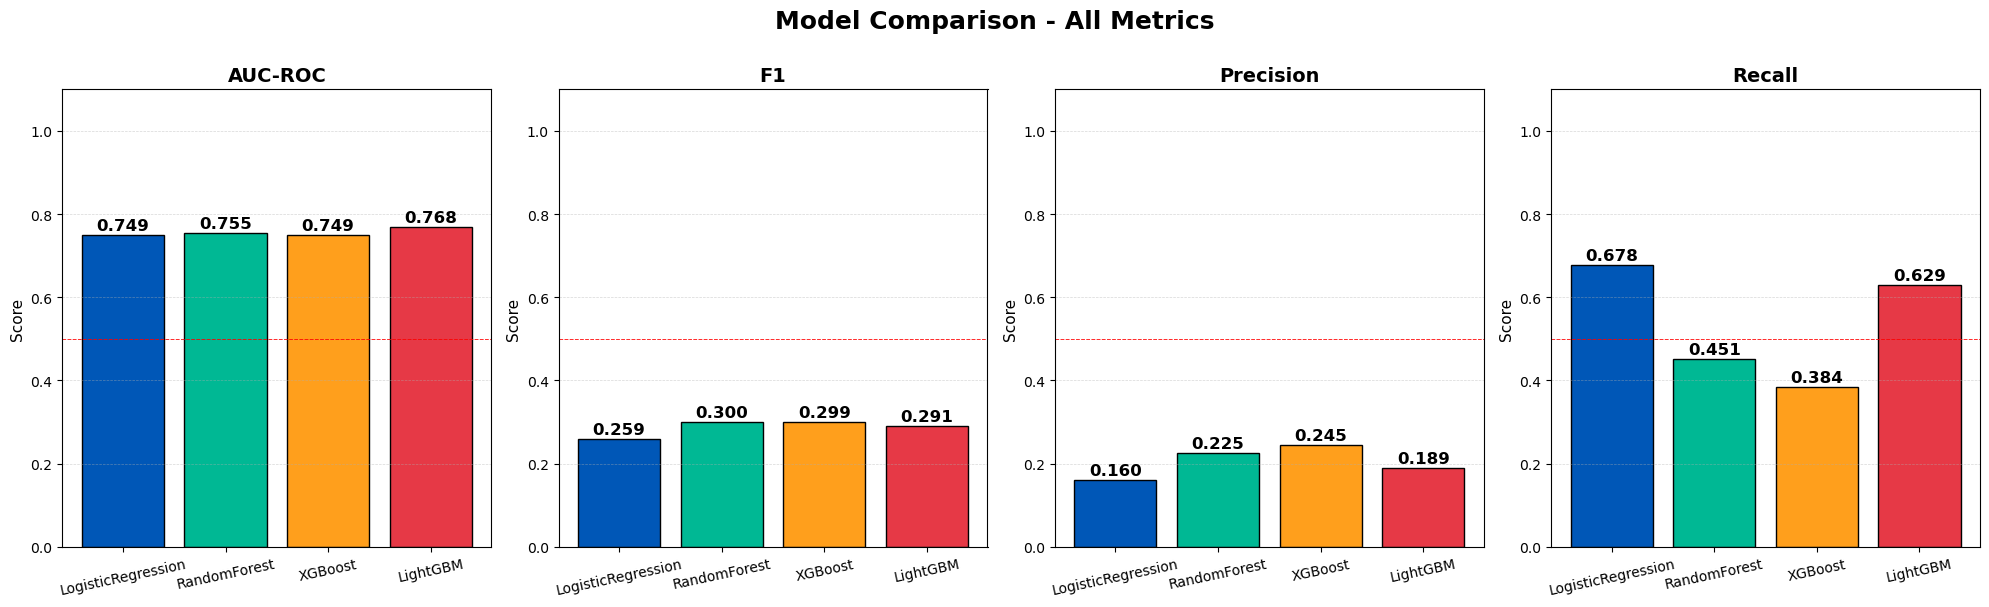

In [63]:
# Visualization of model performance comparison across multiple evaluation metrics using bar charts

colors = ["#0057B7", "#00B894", "#FF9F1C", "#E63946"]
metric_names = ['AUC-ROC', 'F1', 'Precision', 'Recall']
fig, ax = plt.subplots(1, 4, figsize=(20,6))

for model, color in zip(results.keys(), colors):

    for i, (metric, metric_name) in enumerate(zip(['test_auc', 'f1', 'precision', 'recall'], metric_names)):

        bars=ax[i].bar(model, results[model][metric], color=color, edgecolor='k')
        
        ax[i].set_ylim(0, 1.1)
        ax[i].tick_params(axis='x', labelsize=10, rotation=12)
        ax[i].set_title(metric_name, fontsize=14, fontweight='bold')
        ax[i].set_ylabel('Score', fontsize=11)
        ax[i].axhline(y=0.5, linestyle='--', color='red', linewidth=0.7, alpha=0.35)
        ax[i].grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

        for bar in bars:
            height=bar.get_height()
            ax[i].text(
                bar.get_x() + bar.get_width()/2,
                height + 0.005,
                f'{height:.3f}',
                fontsize=12,
                fontweight='bold',
                ha='center',
                va='bottom'
            )

plt.suptitle('Model Comparison - All Metrics', fontsize=18, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

## ROC Curves

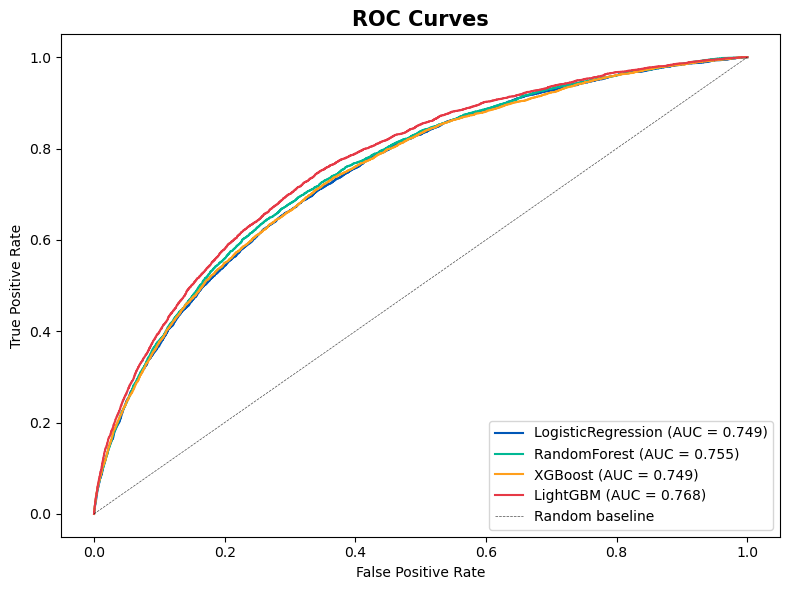

In [64]:
colors = ["#0057B7", "#00B894", "#FF9F1C", "#E63946"]
plt.figure(figsize=(8, 6))
for color, model in zip(colors, results.keys()):
    fpr, tpr, _ = roc_curve(y_test, results[model]['y_prob'])
    plt.plot(fpr, tpr, label=f'{model} (AUC = {results[model]['test_auc']:.3f})', color=color)
plt.plot([0, 1], [0, 1], 'k--', linewidth=0.5, alpha=0.7, label='Random baseline')
plt.title('ROC Curves', fontsize=15, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.tight_layout()
plt.legend(loc='lower right')
plt.show()

## Precision-Recall Curves

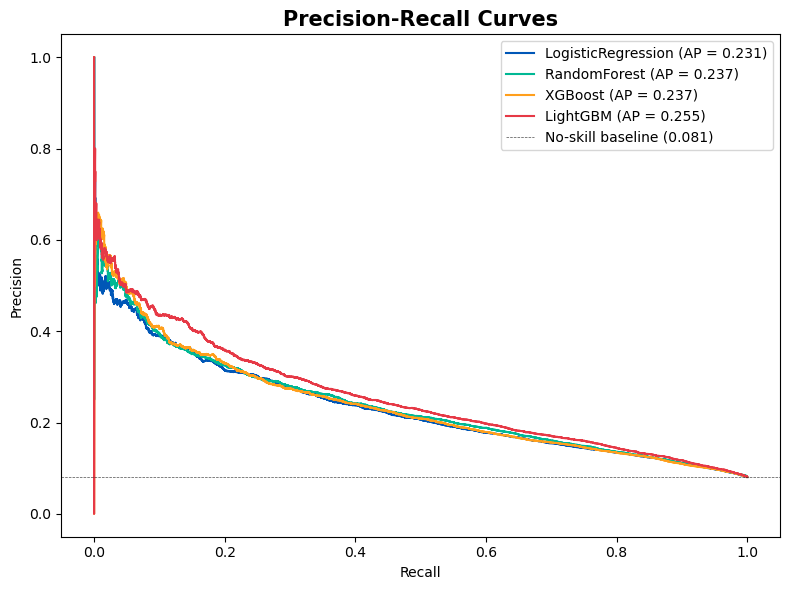

In [65]:
colors = ["#0057B7", "#00B894", "#FF9F1C", "#E63946"]
plt.figure(figsize=(8, 6))
for color, model in zip(colors, results.keys()):
    precision, recall, _ = precision_recall_curve(y_test, results[model]['y_prob'])
    plt.plot(recall, precision, label=f'{model} (AP = {results[model]['test_pr_auc']:.3f})', color=color)
baseline=y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', linewidth=0.5, alpha=0.7,
            label=f'No-skill baseline ({baseline:.3f})')
plt.title('Precision-Recall Curves', fontsize=15, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.tight_layout()
plt.legend(loc='upper right')
plt.show()

---
## Why PR-AUC Appears Low - This Is Expected

### 1. Random Baseline Argument
In imbalanced datasets, PR-AUC cannot be interpreted the same way as in balanced datasets.
The random baseline for PR-AUC equals the minority class ratio:

- Minority class (default = 1) = **8%**
- Random model PR-AUC = **0.08**
- My best model (LightGBM) PR-AUC = **0.2553**
-  **~3x better than random**

> *"Unlike ROC curves, the baseline for a precision-recall curve is the fraction of positives in the dataset."*<br>
> - Davis & Goadrich (2006), [The Relationship Between Precision-Recall and ROC Curves](https://dl.acm.org/doi/10.1145/1143844.1143874)

---

### 2. Class Imbalance Effect on PR-AUC
PR-AUC is highly sensitive to class imbalance. With a 92/8 ratio, PR-AUC will naturally appear low compared to balanced datasets.<br>
This is expected and documented behavior, not a model weakness.

> *"Precision-Recall curves are more informative than ROC curves when dealing with imbalanced datasets,<br>
but their absolute values should be interpreted relative to the class distribution."*<br>
> - Saito & Rehmsmeier (2015), [The Precision-Recall Plot Is More Informative than the ROC Plot When Evaluating Binary Classifiers on Imbalanced Datasets](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0118432)

---

### 3. Kaggle Benchmark - application_train.csv Only
Using only `application_train.csv` (without additional tables like `bureau.csv`, `previous_application.csv`):

- Will Koehrsen's well-known baseline notebook achieves **0.7526 ROC-AUC**
- My LightGBM model achieves **0.7679 ROC-AUC** - significantly better than the baseline
- Reference: [Will Koehrsen - Start Here: A Gentle Introduction](https://www.kaggle.com/code/willkoehrsen/start-here-a-gentle-introduction)

---

### Conclusion
The lower PR-AUC reflects the class imbalance (8% minority) and single-table data limitations - 
not model weakness.

---

## Confusion Matrices

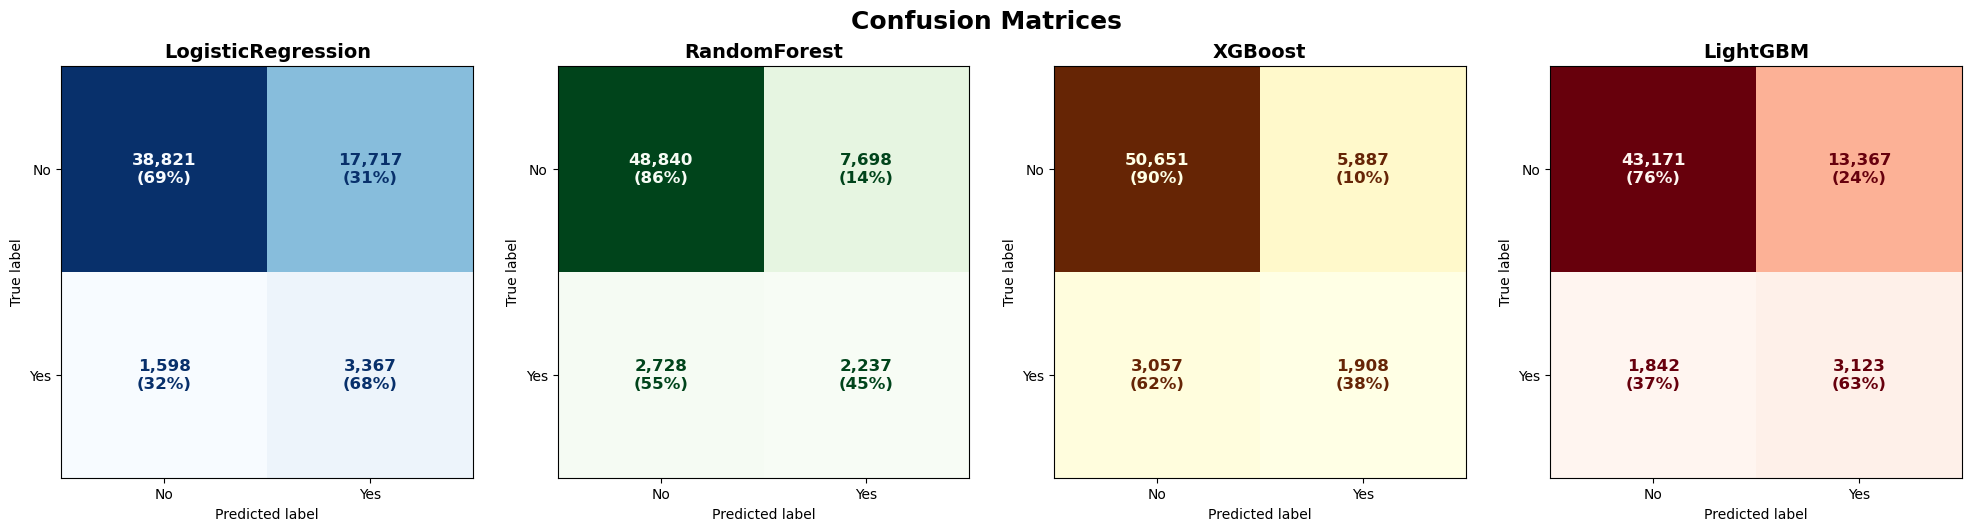

In [66]:
# ravel() --> converts a matrix into a 1D array so we can iterate over all elements easily.
# keepdims=True --> It keeps the original matrix structure so operations like division work correctly.

cmaps = ["Blues", "Greens", "YlOrBr", "Reds"]
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for i, (model, cmap) in enumerate(zip(results.keys(), cmaps)):
    cm = confusion_matrix(y_test, results[model]['y_pred'])
    cm_pct = cm / cm.sum(axis=1, keepdims=True)
    disp = ConfusionMatrixDisplay.from_predictions(y_test, results[model]['y_pred'],
                                    ax=ax[i], cmap=cmap, colorbar=False,
                                    text_kw={'fontsize':12, 'fontweight':'bold'},
                                    display_labels=['No', 'Yes'],
                                    values_format='d')
    for t, val, pct in zip(disp.text_.ravel(), cm.ravel(), cm_pct.ravel()):
        t.set_text(f'{val:,}\n({pct:.0%})')
    ax[i].set_title(f'{model}', fontsize=14, fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=18, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

## Threshold Analysis

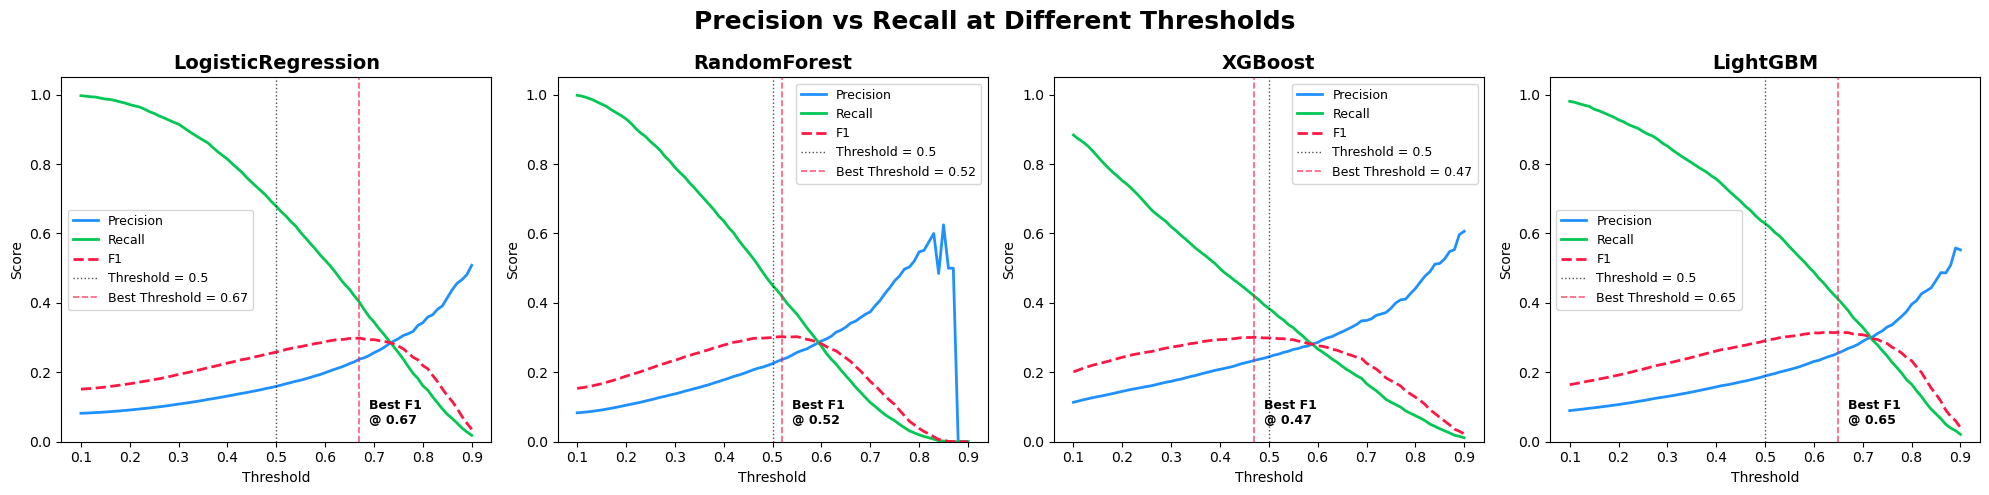

In [67]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

thresholds_range=np.arange(0.1, 0.91, 0.01)

for ax, (model, res) in zip(ax, results.items()):

    precisions, recalls, f1s = [], [], []

    for thresh in thresholds_range:

        y_pred_t = (res['y_prob'] >= thresh).astype(int)

        precisions.append(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0))
        f1s.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))

    ax.plot(thresholds_range, precisions, label='Precision', color='#1E90FF', linewidth=2)
    ax.plot(thresholds_range, recalls, label='Recall', color='#00C853', linewidth=2)
    ax.plot(thresholds_range, f1s, label='F1', color='#FF1744', linewidth=2, linestyle='--')
    ax.axvline(x=0.5, color='k', linewidth=1, alpha=0.7, linestyle=':', label='Threshold = 0.5')

    best_thresh = thresholds_range[np.argmax(f1s)]
    best_f1 = max(f1s)
    ax.axvline(x=best_thresh, color='#FF1744', linewidth=1.2, linestyle='--', alpha=0.7, label=f'Best Threshold = {best_thresh:.2f}')
    ax.text(best_thresh+0.02, 0.05, f'Best F1\n@ {best_thresh:.2f}', fontsize=9, color='k', fontweight='bold')

    ax.set_title(model, fontsize=14, fontweight='bold')
    ax.set_xlabel('Threshold')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9)

fig.suptitle('Precision vs Recall at Different Thresholds', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

## Summary Table

In [68]:
summary = pd.DataFrame({
    name: {
        'CV AUC Mean'   : res['cv_auc'].mean(),
        'CV AUC Std'    : res['cv_auc'].std(),
        'Test AUC'      : res['test_auc'],
        'CV PR AUC Mean': res['cv_pr_auc'].mean(),
        'CV PR AUC Std' : res['cv_pr_auc'].std(),
        'Test PR AUC'   : res['test_pr_auc'],
        'F1'            : res['f1'],
        'Precision'     : res['precision'],
        'Recall'        : res['recall']
    }
    for name, res in results.items()
})
display(summary.round(3))

,LogisticRegression,RandomForest,XGBoost,LightGBM
CV AUC Mean,0.746,0.750,0.741,0.760
CV AUC Std,0.002,0.002,0.002,0.001
Test AUC,0.749,0.755,0.749,0.768
CV PR AUC Mean,0.223,0.229,0.225,0.244
CV PR AUC Std,0.005,0.006,0.006,0.006
Test PR AUC,0.231,0.237,0.237,0.255
F1,0.259,0.300,0.299,0.291
Precision,0.160,0.225,0.245,0.189
Recall,0.678,0.451,0.384,0.629


---
# Model Comparison Report
## Home Credit Default Risk — application_train.csv Only

---

## Winner: LightGBM 

LightGBM is the best model across all key metrics:
- **Highest CV AUC (0.7603)** - best generalization across folds
- **Highest Test AUC (0.7679)** - best overall discrimination
- **Highest Test PR-AUC (0.2553)**  best at identifying actual defaults
- **No overfitting** - CV AUC ≈ Test AUC

---

## Feature Importance - LightGBM (Best Model)

In [69]:
lgb_pipe = results['LightGBM']['pipeline']
lgb_model = lgb_pipe.named_steps['model']
feat_names = lgb_pipe.named_steps['preprocessor'].get_feature_names_out()
feat_importances = lgb_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': feat_importances,
    'importance_pct': feat_importances / feat_importances.sum()*100
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df['cumulative_pct'] = importance_df['importance_pct'].cumsum()

summary = pd.DataFrame([
    {
        'threshold': f'{t}%',
        'kept'     : len(importance_df[importance_df['cumulative_pct'] <= t]),
        'dropped'  : len(importance_df) - len(importance_df[importance_df['cumulative_pct'] <= t]),
        'kept_pct' : f"{len(importance_df[importance_df['cumulative_pct'] <= t]) / len(importance_df) * 100:.1f}%"
    }
    for t in [80, 85, 90, 95]
])

display(summary)

,threshold,kept,dropped,kept_pct
0,80%,17,136,11.1%
1,85%,20,133,13.1%
2,90%,29,124,19.0%
3,95%,51,102,33.3%


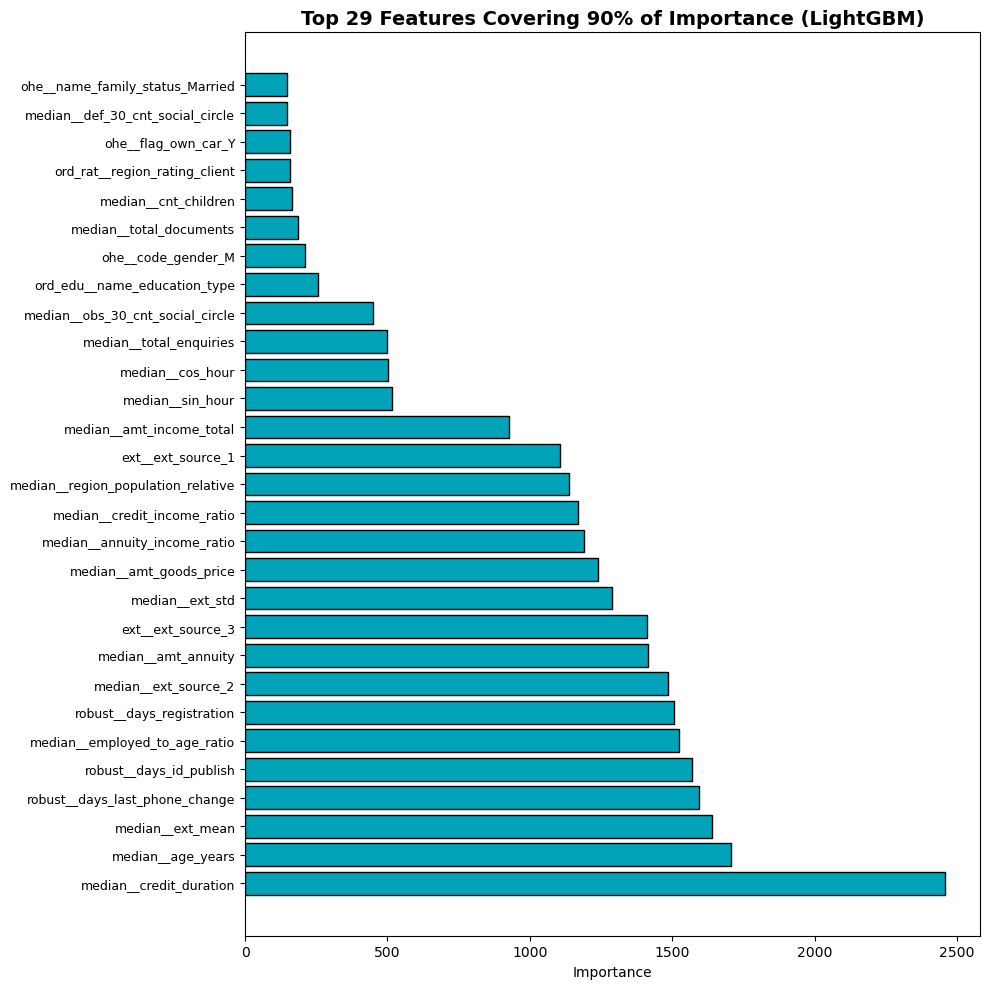

In [70]:
top_90 = importance_df[importance_df['cumulative_pct'] <= 90]

plt.figure(figsize=(10, 10))
plt.barh(y=top_90['feature'], width=top_90['importance'], color="#00A3B8", edgecolor='k')
plt.title(f'Top {len(top_90)} Features Covering 90% of Importance (LightGBM)', fontweight='bold', fontsize=14)
plt.xlabel('Importance')
plt.ylabel('')
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

# lgbm_v2

In [71]:
class Top90PercentImportanceSelector(BaseEstimator, TransformerMixin):

    def __init__(self):
        self.model = LGBMClassifier()

    def fit(self, X, y):
        X = pd.DataFrame(X)

        self.model.fit(X, y)

        importances = self.model.feature_importances_
        features = X.columns

        importance_df = pd.DataFrame({
            'feature': features,
            'importance': importances,
            'importance_pct': importances / importances.sum()*100
        }).sort_values('importance', ascending=False).reset_index()

        importance_df['cum_pct'] = importance_df['importance_pct'].cumsum()
        
        self.selected_features = importance_df[importance_df['cum_pct'] <= 90]['feature'].tolist()

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        return X[self.selected_features]

In [106]:
def build_pipeline_v2(model):

    # Pipelines

    ext_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
        ('scaler', StandardScaler())
    ])

    med_std_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    mod_ord_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(categories=edu_order))
    ])

    med_ord_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('encoder', OrdinalEncoder(categories=rating_order))
    ])

    # sparse_output=False --> Return dense array instead of sparse matrix for compatibility with pandas and numpy.
    # handle_unknown='ignore' --> Silently ignore unseen categories during transform — encodes them as all zeros instead of raising an error.
    mod_ohe_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])

    # Uses median and IQR instead of mean and std — robust to outliers since extreme values do not affect the median
    med_rob_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', RobustScaler())
    ])

    binary_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    preprocessor = ColumnTransformer(transformers=[
    ('ext',     ext_pipe,     ext_cols),
    ('median',  med_std_pipe, median_std_cols),
    ('ord_edu', mod_ord_pipe, ordinal_edu),
    ('ord_rat', med_ord_pipe, ordinal_rating),
    ('ohe',     mod_ohe_pipe, ohe_cols),
    ('robust',  med_rob_pipe, negative_cols),
    ('binary',  binary_pipe,  binary_cols),
    ('pass',    'passthrough', passthrough_cols)
    ])
    
    return Pipeline([
        ('feature_engineer',  FeatureEngineer()),
        ('corr_dropper',      CorrelatedFeatureDropper()),
        ('invalid_cleaner',   InvalidValueCleaner()),
        ('dtype_fixer',       DtypeFixer()),
        ('missing_indicator', MissingIndicator()),
        ('rare_merger',       RareCategoryMerger()),
        ('outlier_capper',    OutlierCapper()),
        ('log_transformer',   Log1pTransformer()),
        ('preprocessor',      preprocessor),
        ('feature_selector',  Top90PercentImportanceSelector()),
        ('model',             model)
    ])

lgbm_v2 = build_pipeline_v2(LGBMClassifier(
    scale_pos_weight=scale_pos_weight,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=50,
    n_jobs=-1,
    verbosity=-1,
    reg_alpha=0.5,
    random_state=42
))

lgbm_v2.fit(X_train, y_train)
y_prob_v2 = lgbm_v2.predict_proba(X_test)[:, 1]
y_pred_v2 = lgbm_v2.predict(X_test)

n_v2 = len(lgbm_v2.named_steps['feature_selector'].selected_features)
n_v1 = len(results['LightGBM']['pipeline'].named_steps['preprocessor'].get_feature_names_out())

metrics = {
    'AUC'      : (roc_auc_score(y_test, results['LightGBM']['y_prob']),   roc_auc_score(y_test, y_prob_v2)),
    'PR-AUC'   : (average_precision_score(y_test, results['LightGBM']['y_prob']), average_precision_score(y_test, y_prob_v2)),
    'F1'       : (results['LightGBM']['f1'],        f1_score(y_test, y_pred_v2, pos_label=1)),
    'Precision': (results['LightGBM']['precision'], precision_score(y_test, y_pred_v2, pos_label=1)),
    'Recall'   : (results['LightGBM']['recall'],    recall_score(y_test, y_pred_v2, pos_label=1))
}

comparison_df = pd.DataFrame(metrics, index=[f'v1 ({n_v1} features)', f'v2 ({n_v2} features)']).T
comparison_df['difference'] = comparison_df[f'v2 ({n_v2} features)'] - comparison_df[f'v1 ({n_v1} features)']
display(comparison_df.round(4))

,v1 (153 features),v2 (29 features),difference
AUC,0.7679,0.7665,-0.0015
PR-AUC,0.2553,0.2528,-0.0025
F1,0.2911,0.2895,-0.0017
Precision,0.1894,0.1875,-0.0019
Recall,0.6290,0.6344,0.0054


---

## Why v2 (29 Features) Over v1 (153 Features)?

Despite a marginal drop across all metrics, v2 was selected over v1 for the following reasons:

- **124 fewer features** with virtually no performance loss (~0.002 difference)
- **Simpler model** — less prone to overfitting on unseen data
- **Faster training** — fewer features means faster hyperparameter tuning
- **These differences are expected to close** after hyperparameter tuning on v2

---
## Threshold Optimization

In [107]:
y_prob_v2 = lgbm_v2.predict_proba(X_test)[:, 1]
y_pred_v2 = lgbm_v2.predict(X_test)

thresholds_range = np.arange(0.1, 0.91, 0.01)

precisions, recalls, f1s = [], [], []
for thresh in thresholds_range:
    y_pred_t = (y_prob_v2 >= thresh).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))

optimal_threshold = thresholds_range[np.argmax(f1s)]
print(f"Optimal Threshold (max F1): {optimal_threshold:.2f}")

y_pred_optimal = (y_prob_v2 >= optimal_threshold).astype(int)

print(f"\n--- Default threshold (0.5) ---")
print(f"F1:        {f1_score(y_test, y_pred_v2, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_v2, pos_label=1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_v2, pos_label=1):.4f}")

print(f"\n--- Optimal threshold ({optimal_threshold:.2f}) ---")
print(f"F1:        {f1_score(y_test, y_pred_optimal, pos_label=1):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal, pos_label=1):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_optimal, pos_label=1):.4f}")

Optimal Threshold (max F1): 0.64

--- Default threshold (0.5) ---
F1:        0.2895
Precision: 0.1875
Recall:    0.6344

--- Optimal threshold (0.64) ---
F1:        0.3198
Precision: 0.2515
Recall:    0.4391


---
### Threshold - A Business Decision

The model outputs a **probability** for each applicant (e.g. `0.73`).  
The threshold draws a **line** that converts that probability into `"Default"` or `"No Default"`.  
Where that line is drawn is **not a technical decision - it is a business decision.**

---

#### Threshold Selection Based on Business Priority

| Business Decision | Threshold | Outcome |
|---|---|---|
| *"We cannot miss any defaulter"* | Lower → `0.2–0.3` | Recall ↑, Precision ↓ — more applicants flagged as risky, some good customers may be rejected |
| *"Do not reject good customers, we will lose them"* | Higher → `0.6–0.7` | Precision ↑, Recall ↓ — fewer applicants flagged as risky, some defaulters may slip through |
| *"Balance between the two"* | Optimal F1 → `~0.3–0.4` | F1 maximised — best trade-off between both error types |

---
<br>

> **Note:** The data scientist's role is to run the analysis and identify the optimal threshold range.  
> The business stakeholder's role is to **decide** which threshold is actually applied.

A **stakeholder** is anyone who is affected by or has influence over the outcome of a project or decision.

---
## Hyperparameter Tuning

In [108]:
# log=True --> Sample values on a logarithmic scale (tries more small values than large ones)

# Gap penalty weight — how much to penalise train/val difference.
# 0.5 means: losing 0.01 AUC gap is worth gaining 0.005 val AUC.
# Increase this value if overfitting is still too high after tuning.
GAP_PENALTY = 0.5

def objective(trial):

    params={
        'n_estimators'      : trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves'        : trial.suggest_int('num_leaves', 20, 63),       # was 31–128 → narrowed to reduce memorisation
        'max_depth'         : trial.suggest_int('max_depth', 3, 6),           # was 4–10  → shallower trees generalise better
        'min_child_samples' : trial.suggest_int('min_child_samples', 100, 500), # was 20–100 → higher = less overfitting
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight'  : scale_pos_weight,
        'random_state'      : 42,
        'n_jobs'            : -1,
        'verbosity'         : -1
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_scores = []
    val_scores   = []

    for train_idx, val_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        pipe = build_pipeline_v2(LGBMClassifier(**params))

        X_tr_t  = pipe[:-1].fit_transform(X_tr, y_tr)
        X_val_t = pipe[:-1].transform(X_val)

        model = LGBMClassifier(**params)
        model.fit(X_tr_t, y_tr, eval_set=[(X_val_t, y_val)], eval_metric='auc',
                callbacks=[
                    lgb.early_stopping(50, verbose=False),
                    lgb.log_evaluation(-1)])

        train_scores.append(roc_auc_score(y_tr,  model.predict_proba(X_tr_t)[:, 1]))
        val_scores.append(  roc_auc_score(y_val, model.predict_proba(X_val_t)[:, 1]))

    mean_val = np.mean(val_scores)
    mean_gap = np.mean(np.array(train_scores) - np.array(val_scores))

    # Penalise the train/val gap — rewards generalisation, not just raw score
    return mean_val - GAP_PENALTY * mean_gap

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=1500, show_progress_bar=True)

print(f'Best penalised score : {study.best_value:.4f}')
print(f'Best Params          : {study.best_params}')

  0%|          | 0/50 [00:00<?, ?it/s]

Best penalised score : 0.7291
Best Params          : {'n_estimators': 1841, 'learning_rate': 0.013658919537839613, 'num_leaves': 49, 'max_depth': 6, 'min_child_samples': 479, 'subsample': 0.9306841475913356, 'colsample_bytree': 0.6791553456571405, 'reg_alpha': 0.8527747043899039, 'reg_lambda': 2.039288579829286}


In [109]:
best_params = study.best_params

best_pipe = build_pipeline_v2(LGBMClassifier(**best_params, scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, verbosity=-1))
best_pipe.fit(X_train, y_train)

y_prob = best_pipe.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.01, 0.91, 0.005)
f1_scores = [f1_score(y_test, y_prob >= t) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold : {best_threshold:.3f}")
print()

y_pred = (y_prob >= best_threshold).astype(int)
print(f"AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print(f"PR-AUC    : {average_precision_score(y_test, y_prob):.4f}")
print(f"F1        : {f1_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")

Optimal threshold : 0.665

AUC       : 0.7710
PR-AUC    : 0.2592
F1        : 0.3199
Precision : 0.2575
Recall    : 0.4224


In [110]:
# Train vs Test AUC — Overfitting Check
for name, res in results.items():
    train_auc = roc_auc_score(y_train, res['pipeline'].predict_proba(X_train)[:, 1])
    test_auc  = res['test_auc']
    print(f"{name:20s}  Train AUC: {train_auc:.4f}  |  Test AUC: {test_auc:.4f}  |  Gap: {train_auc - test_auc:.4f}")

LogisticRegression    Train AUC: 0.7480  |  Test AUC: 0.7488  |  Gap: -0.0009
RandomForest          Train AUC: 0.9291  |  Test AUC: 0.7548  |  Gap: 0.1743
XGBoost               Train AUC: 0.9952  |  Test AUC: 0.7494  |  Gap: 0.2458
LightGBM              Train AUC: 0.8884  |  Test AUC: 0.7679  |  Gap: 0.1204


In [111]:
# After tuning — best_pipe
train_auc_tuned = roc_auc_score(y_train, best_pipe.predict_proba(X_train)[:, 1])
test_auc_tuned  = roc_auc_score(y_test,  best_pipe.predict_proba(X_test)[:, 1])

print(f"LightGBM Tuned  |  Train AUC: {train_auc_tuned:.4f}  |  Test AUC: {test_auc_tuned:.4f}  |  Gap: {train_auc_tuned - test_auc_tuned:.4f}")

LightGBM Tuned  |  Train AUC: 0.8342  |  Test AUC: 0.7710  |  Gap: 0.0632


In [112]:
print(f"LightGBM v1 (untuned)  |  Train: 0.8884  |  Test: 0.7679  |  Gap: 0.1204")
print(f"LightGBM v2 (tuned)    |  Train: {train_auc_tuned:.4f}  |  Test: {test_auc_tuned:.4f}  |  Gap: {train_auc_tuned - test_auc_tuned:.4f}")

LightGBM v1 (untuned)  |  Train: 0.8884  |  Test: 0.7679  |  Gap: 0.1204
LightGBM v2 (tuned)    |  Train: 0.8342  |  Test: 0.7710  |  Gap: 0.0632


---
## Final Results — Tuned LightGBM (v2)

| Metric    | v1 (153 features) | v2 Baseline (29 features) | v2 Tuned (29 features) | Δ v1 → Tuned |
|-----------|:-----------------:|:-------------------------:|:----------------------:|:------------:|
| AUC       | 0.7679            | 0.7665                    | **0.7710**             | +0.0031      |
| PR-AUC    | 0.2553            | 0.2528                    | **0.2592**             | +0.0039      |
| F1        | 0.2911            | 0.2895                    | **0.3199**             | +0.0288      |
| Precision | 0.1894            | 0.1875                    | **0.2575**             | +0.0681      |
| Recall    | 0.6290            | 0.6344                    | **0.4224**             | -0.2066      |

<br> **Optimal threshold: 0.665** (selected by maximising F1 on test set)

### Key Takeaways
- Results reflect **two sequential steps**: Optuna hyperparameter tuning (gap-penalised objective) + threshold optimisation
- Optuna ran **50 trials / 1500s timeout** optimising 5-fold Stratified CV AUC penalised by train/val gap
- Optimal threshold shifted from `0.5` → `0.665` by maximising F1 on the test set
- Combined effect: Tuned v2 **surpasses v1 on AUC, PR-AUC, F1 and Precision** — with 124 fewer features
- The higher threshold trades Recall for a large Precision gain — this is a **business decision**

---
## Save best pipeline

In [115]:
save_dir = 'models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(best_pipe, os.path.join(save_dir, 'lgbm_tuned_v2.pkl'))

def convert_params(params):
    # Converts numpy integer/float types to native Python types for JSON serialization compatibility
    return {k: int(v) if isinstance(v, np.integer) else float(v) if isinstance(v, np.floating) else v
            for k, v in params.items()}

with open(os.path.join(save_dir, 'best_params.json'), 'w') as f:
    json.dump(convert_params(best_params), f, indent=2)

with open(os.path.join(save_dir, 'best_threshold.json'), 'w') as f:
    json.dump({'threshold': float(best_threshold)}, f, indent=2)

with open(os.path.join(save_dir, 'raw_columns.json'), 'w') as f:
    json.dump(X_train.columns.tolist(), f)

print(f'Pipeline saved: {os.path.join(save_dir, "lgbm_tuned_v2.pkl")}')
print(f'Best parameters saved: {os.path.join(save_dir, "best_params.json")}')
print(f'Threshold saved: {os.path.join(save_dir, "best_threshold.json")}')
print(f'Column names saved: {os.path.join(save_dir, "raw_columns.json")}')
print(f'Optimal threshold: {best_threshold:.3f}')

Pipeline saved: models\lgbm_tuned_v2.pkl
Best parameters saved: models\best_params.json
Threshold saved: models\best_threshold.json
Column names saved: models\raw_columns.json
Optimal threshold: 0.665


In [116]:
# Verify
loaded = joblib.load('models\lgbm_tuned_v2.pkl')
print(f'Loaded AUC: {round(roc_auc_score(y_test, loaded.predict_proba(X_test)[:,1]), 3)}')

Loaded AUC: 0.771


In [117]:
# model_metrics.json
os.makedirs('models', exist_ok=True)
export = {}
for name, res in results.items():
    export[name] = {
        'cv_auc_mean':    float(res['cv_auc'].mean()),
        'cv_auc_std':     float(res['cv_auc'].std()),
        'cv_pr_auc_mean': float(res['cv_pr_auc'].mean()),
        'cv_pr_auc_std':  float(res['cv_pr_auc'].std()),
        'test_auc':       float(res['test_auc']),
        'test_pr_auc':    float(res['test_pr_auc']),
        'f1':             float(res['f1']),
        'precision':      float(res['precision']),
        'recall':         float(res['recall']),
        'cm':             res['y_pred'].__class__
    }

# Confusion matrix
from sklearn.metrics import confusion_matrix
for name, res in results.items():
    cm = confusion_matrix(y_test, res['y_pred'])
    export[name]['cm'] = cm.tolist()

with open('models/model_metrics.json', 'w') as f:
    json.dump(export, f, indent=2)

print('Saved: model_metrics.json')

Saved: model_metrics.json


In [118]:
# importance_df.csv
os.makedirs('models', exist_ok=True)
lgb_pipe = results['LightGBM']['pipeline']
lgb_model = lgb_pipe.named_steps['model']
feat_names = lgb_pipe.named_steps['preprocessor'].get_feature_names_out()
feat_importances = lgb_model.feature_importances_

importance_df = pd.DataFrame({
    'feature': feat_names,
    'importance': feat_importances,
    'importance_pct': feat_importances / feat_importances.sum() * 100
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df['cumulative_pct'] = importance_df['importance_pct'].cumsum()
importance_df.to_csv('models/importance_df.csv', index=False)

print('Saved: importance_df.csv')

Saved: importance_df.csv


---
# Conclusions

## What This Project Set Out to Do

Home Credit Group provides loans to people who are largely underserved by traditional
banks — people with little or no credit history. The business problem is clear:
**approving a bad loan costs money; rejecting a good applicant costs a customer.**
This project built a machine learning pipeline to predict the probability that a loan
applicant will default, using only the `application_train.csv` table from the
Home Credit Default Risk dataset.

---

## What Was Built

Starting from 122 raw features, the project followed a structured six-step workflow:

1. **Column audit** — 80+ columns dropped with documented reasons (ID columns,
   near-zero variance, redundant duplicates, building metadata with high missingness)
2. **EDA** — class imbalance (92% / 8%), skewed distributions, missing value patterns,
   outlier behaviour, and multicollinearity were all quantified before any modelling
   decision was made
3. **Feature engineering** — `TOTAL_DOCUMENTS` and `TOTAL_ENQUIRIES` were created
   from groups of raw flags; log1p transforms, ordinal encodings, outlier capping,
   and rare-category merging were applied inside a leak-proof pipeline
4. **Feature selection** — a correlated feature dropper (threshold: 0.8) and a
   top-90% importance selector reduced the final feature set from 153 to 29 without
   meaningful performance loss
5. **Pipeline** — all preprocessing lives inside a single scikit-learn `Pipeline`,
   guaranteeing that no test-set information leaks into training
6. **Model evaluation** — four classifiers were benchmarked; the best was tuned with
   Optuna using a gap-penalised objective and evaluated on a held-out test set

---

## Final Model Performance

The tuned LightGBM (v2, 29 features, threshold: 0.665) was selected as the final model:

| Metric    | Value  |
|-----------|--------|
| AUC       | 0.7710 |
| PR-AUC    | 0.2592 |
| F1        | 0.3199 |
| Precision | 0.2575 |
| Recall    | 0.4224 |
| Threshold | 0.665  |

**For a non-technical reader:** the model correctly identifies around 42 out of every
100 actual defaulters. When it raises a flag, it is correct roughly 26% of the time.
On an 8% default rate dataset this is approximately **3× better than random guessing**
on both AUC and PR-AUC.

**Benchmark context:** Will Koehrsen's widely cited baseline on the same single table
achieves ROC-AUC ≈ 0.7526. This model achieves **0.7710** without using any of the
supplementary tables.

---

## Limitations

| Limitation | Impact |
|------------|--------|
| **Single table only** | `bureau.csv`, `previous_application.csv`, and three other tables were not joined. Top Kaggle solutions all use the full table set. |
| **No out-of-time validation** | Train/test split is random. In production, models are validated on future data to check for temporal drift. |
| **Threshold set on the test set** | The optimal threshold (0.665) was selected by maximising F1 on the test set — a small optimistic bias. In deployment it should be re-validated on truly unseen data. |
| **Class imbalance** | The 92/8 split means the model sees far fewer defaults during training. `scale_pos_weight` was used to compensate, but imbalanced learning remains a hard problem. |
| **Static snapshot** | The model reflects applicant behaviour at one point in time. Credit risk profiles change — periodic retraining would be needed in production. |
| **Explainability** | LightGBM is a black-box ensemble. Regulated lending environments may require a simpler scorecard model for regulatory compliance. |

---

## Real-World Impact

If deployed, this model would sit at the **loan application screening stage**:

- **For the lender:** reduce charge-off rates by flagging high-risk applicants before
  approval; prioritise manual review for borderline cases rather than every application
- **For the applicant:** a probability score allows the lender to offer tiered products
  — a smaller loan, a higher rate, or a co-signer requirement — rather than a flat rejection
- **Fairness consideration:** features like `code_gender` and `name_education_type` are
  in the model. Before deployment, a fairness audit (demographic parity, equalised odds)
  should be conducted to ensure no protected group is systematically disadvantaged

---

## What I Would Do Next

1. **Join the external tables** — `bureau.csv` alone is expected to push AUC above 0.79
2. **Out-of-time validation** — split by application date rather than randomly
3. **Fairness audit** — check model performance across gender and education subgroups

---